# Bienor Light Curve

In this Jupyter Notebook, we aim to obtain the light curve of Bienor.

The data are organized in the following folders:

- `Bienor_Light_curve` → Observations from **20/02/2026**

### Data of the Telescope:

- Observatory: Pujalt Observatory, Barcelona

- Telescope: CDK20 (508.0 mm)

- Type Filter: Clear

Next, the shadow path of Biennor on the day of the occultation is shown, along with the telescopes that observed the event. In green, a positive detection of the observation is obtained, and in red, a negative detection.

![Occultation portal screenshot](/home/franeko/IAA/occultation_portal/Bienor/occultationportal-screenshot.png)




Los pasos a seguir para obtener la curva de luz serian los siguientes:

- Identificar la estrella la cual se oculta por medio del objeto transneptuniano. Se puede hacer convirtiendo las coordenadas celestes a coordenadas en pixeles, o como en nuestro caso de manera mas asrtesanal creando un gift sabiendo que la ocultacion se va a dar en las zonas centrales de la imagen.

- Una vez identificada la estrella las imagenes se deben alinear. Aunque se tiene la falsa creencia de que como el telescopio sigue a la estrella todas las imagenes van a estar completamente alineadas es falsa. Las imagenes tienen un cierto movmiento con respecto al primer frame que provoca que no se encuentre alineadas del todo.

- El tercer paso, es identeficar estrellas con un flujo cercano a la estrella ocultada para poder estudiar su flujo en funcion del tiempo. Como estos datos no tienes BIAS ni FLAT para poder ser corregida tenemos que buscar un metodo el cual noos permita corregir los flujos de las estrellas. Para corregirlos, cogemremos un anillo alrededor de la estrella para calcular la mediana del ruido para poder mas tarde substraer el ruido al flujo de la estrella correspondiente.



In [1]:
import paramiko
import stat
import re

#Create gifts
import imageio

### Python Usual Packages ###

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# Work with astrophysical times
import datetime

### Astrophysics ###

# Align the images
import astroalign as aa

#Change the celestial coordinates
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u

# Astronomical time
from astropy.time import Time

# Aperture stats
from photutils.aperture import ApertureStats

# FWHM fit
from photutils.psf import fit_fwhm

#SORA implementations (prediction, curveligth and Body parameters)
from sora import LightCurve
from sora.prediction import prediction 
from sora.body import Body 

from astropy.io import fits
from photutils.detection import DAOStarFinder
from astropy.stats import sigma_clipped_stats, SigmaClip
from astropy.stats import sigma_clipped_stats

from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry

from astropy.table import Table


from matplotlib import rcParams as rc
rc.update({'font.size': 20,\
           'font.weight': 900,\
           'text.usetex': True,\
           'path.simplify'           :   True,\
           'xtick.labelsize' : 20,\
           'ytick.labelsize' : 20,\
#           'xtick.major.size' : 3.5,\
#           'ytick.major.size' : 3.5,\
           'axes.linewidth'  : 2.0,\
               # Increase the tick-mark lengths (defaults are 4 and 2)
           'xtick.major.size'        :   6,\
           'ytick.major.size'        :   6,\
           'xtick.minor.size'        :   3,\
           'ytick.minor.size'        :   3,\
           'xtick.major.width'       :   1,\
           'ytick.major.width'       :   1,\
           'lines.markeredgewidth'   :   1,\
           'legend.numpoints'        :   1,\
           'xtick.minor.width'       :   1,\
           'ytick.minor.width'       :   1,\
           'legend.frameon'          :   False,\
           'legend.handletextpad'    :   0.3,\
           'font.family'    :   'serif',\
           'mathtext.fontset'        :   'stix',\
           'axes.facecolor' : "w",\
           
          })

pd.set_option('display.max_rows', None)

pd.set_option('display.max_columns', None)

pd.set_option('display.max_colwidth', None)

SORA version: 0.3.2


### Observation of Bienor_Light_curve date 20/02/2026

In [ ]:
root = "/home/franeko/IAA/occultation_portal/Bienor/Bienor_Light_curve"   

In [3]:

with fits.open(os.path.join(root,'Biennor_00001.fits')) as hdul:
    hdu = hdul[0].header

In [4]:
hdul.info()

Filename: /home/franeko/IAA/occultation_portal/Bienor_Light_curve/Biennor_00001.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      64   (2080, 1392)   int16 (rescales to uint16)   


In [ ]:
hdu

SIMPLE  =                    T / C# FITS: 02/20/2026 22:56:28                   
BITPIX  =                   16                                                  
NAXIS   =                    2 / Dimensionality                                 
NAXIS1  =                 2080                                                  
NAXIS2  =                 1392                                                  
ADCBITS =                   16 / Bit depth of camera sensor ADC in current mode 
AIRMASS =   1.0056852456235048 / Pickerings formula from target elevation only. 
BIASADU =    95.22444152832031 / ADU for bias level (no photons) at current sett
BLKLEVEL=                   10 /                                                
BSCALE  =                    1 /                                                
BZERO   =                32768 /                                                
CAMID   = '27184F0222000900'   /                                                
CCD-TEMP=                  -

## Determination of the Occulted Star

First, we need to determine which star is being occulted during the observation in order to derive the light curve. Usually, the star is at the center of the image. Normally, to verify in which pixels the star is located, we can convert the celestial coordinates of the star into pixel coordinates using WCS. However (see Appendix 2), this `.fits` file seems to have an issue. For this reason, a GIF will be created to identify in a more manual way which star is being occulted and, using Fiji, determine exactly which pixels it corresponds to in the image.

For our case, in the **first image** the star is located at pixels:  

- **X = 1041**  
- **Y = 698**  

In [ ]:
frames = []

for dirpath, dirnames, filenames in os.walk(root):
    filenames = sorted(filenames)


    for f in filenames:
        if f.upper().endswith(('.FITS', '.FIT')):
            fullpath = os.path.join(dirpath, f)

            with fits.open(fullpath) as hdul:
                data = hdul[0].data

            # Normalization
            vmin = np.median(data) - np.std(data)
            vmax = np.median(data) + np.std(data)
            img = np.clip((data - vmin) / (vmax - vmin), 0, 1)

            # Convert to a 8 bits image
            img = (img * 255).astype(np.uint8)

            frames.append(img)

# Save GIF
 imageio.mimsave("mnt/c/Users/IAA/ animacion.gif", frames, duration=0.2)

Next, the first image taken by the telescope is shown, along with a zoom on the star that will be occulted by the trans-Neptunian object, in this case Biennor.

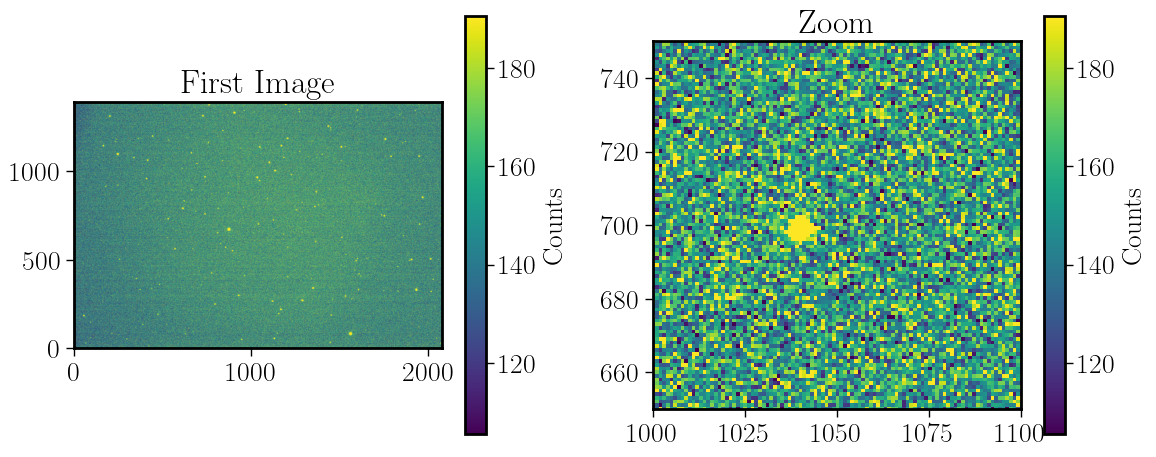

In [80]:
with fits.open(os.path.join(root, 'Biennor_00001.fits')) as hdul:
    data = hdul[0].data

vmin = np.median(data) - np.std(data)
vmax = np.median(data) + np.std(data)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(data, origin='lower', vmin=vmin, vmax=vmax)
axes[0].set_title("First Image")
fig.colorbar(im0, ax=axes[0], label='Counts')


im1 = axes[1].imshow(data, origin='lower', vmin=vmin, vmax=vmax)
axes[1].set_title("Zoom")

axes[1].set_xlim(1000, 1100)
axes[1].set_ylim(650, 750)

fig.colorbar(im1, ax=axes[1], label='Counts')

plt.tight_layout()
plt.show()

## Image Alignment

Once the star is identified in the first image, the next step is to **align all the images**. To do this, we will use the [Astroalign](https://astroalign.quatrope.org/en/latest/) library, which allows us to align images based on a reference image and another given image, as long as it is possible.

The library basically looks for similar 3-point asterisms (triangles) in both images and estimates the affine transformation between them.

In the documentation, there is a simple usage example:

```python
registered_image, footprint = aa.register(source, target)
```

- `source` and `target` are the two images that we want to align.  

- `registered_image` is now a transformed image of `source`.  


⚠️ **IMPORTANT NOTE:** Flux may not be conserved after the transformation.

In [ ]:
with fits.open(os.path.join(root,'Biennor_00001.fits')) as hdul:
    target = hdul[0].data

aligned_images = []

for dirpath, dirnames, filenames in os.walk(root):
    filenames = sorted(filenames)

filenames = filenames[1:]

for file in filenames:
    with fits.open(os.path.join(root, file)) as hdul:
        source = hdul[0].data

        registered_image, footprint = aa.register(source, target)
        aligned_images.append(registered_image)

Since the images are already aligned, we are going to store them in a single 3D array. This will allow us to process them later to extract the stellar light curves.

In [7]:
images_2 =[]

for observation in aligned_images:
    images_2.append(observation[450:975,800:1325])


# imageio.mimsave("slicing.gif", images_2, duration=0.2)

## Identification of near stars and procedure

Now we Select several stars close to the occulted star. This serves two purposes. 

- First, we need to verify that none of the surrounding stars show anomalies in their flux at the time of the occultation; if they do, the observed dip might be due to atmospheric fluctuations during the observation rather than the occultation itself. 

- Second, we will compare the light curves of these stars; however, to make this comparison more reliable, we will construct a synthetic star that helps reduce statistical fluctuations from the selected stars.

- After selecting the stars we want to work with, we process the images one by one. For each image, we take the flux and subtract the background estimated from the annulus around the star (using the median value of that annulus), and store the results in arrays so that we can later plot the light curves.

- Once stored, the flux of each star should be normalized by dividing by the median flux of that star.

- At the same time, we construct the synthetic star as a result of the statistical combination of the analyzed stars.

In [81]:
# I would work in the following section with the slice image [450:975, 800:1325]
# Here we work with the first image for the identification of the stars.

data = target
reduction = data[450:975, 800:1325]

mean, median, std = sigma_clipped_stats(reduction, sigma=15.0)
daofind = DAOStarFinder(fwhm=3.0, threshold=5.*std)
sources = daofind(reduction - median)


As we can see, not all the selected stars have a similar flux. Although we could use all the stars for later comparison, here we will remove those stars whose flux is either too high or too low in order to avoid issues when comparing light curves.

For this reason, both stars 3 and 4, which have fluxes close to 15000 counts, will be excluded.

In [82]:
sources.remove_row(3)
sources.remove_row(8)
sources

id,xcentroid,ycentroid,sharpness,roundness1,roundness2,npix,peak,flux,mag,daofind_mag
int64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64
1,92.49094549869159,98.60691901297679,0.7645820485418775,0.06921624783942126,0.053198820504739903,25,466.0,4536.0,-9.141682614712126,-0.8201798333452694
2,53.82011560116571,117.92376823907757,0.4404398369468922,0.22134250518580073,-0.2337821349359039,25,299.0,3459.0,-8.847376405035904,-0.5422841790520604
3,9.998637805388757,199.17442455641756,0.49791479452089477,0.6543317840883316,0.17101364918972062,25,163.0,1686.0,-8.067143925721808,-0.03331694372827512
5,240.00765787109833,248.94913069054112,0.33633024074232964,0.28756552620303744,0.029954135314960113,25,310.0,4107.0,-9.033811757134131,-0.6888253065077449
6,323.7941871716571,271.6387821412177,0.5287960014012059,0.029905374394439136,-0.1815571849991409,25,348.0,3692.0,-8.918154230884687,-0.6716941990828029
7,454.40422369624076,328.43059013485515,0.3126161591131489,0.5842659291010941,0.4686601928701635,25,188.0,2599.0,-8.537015698752532,-0.042332559002624705
8,485.65583468115653,370.00345590876367,0.7842050919313208,-0.836040333395026,-0.43938197512391725,25,186.0,1463.0,-7.913110815313277,-0.011754581188734639
9,244.86943834500934,494.34945017715916,0.25790517778732636,0.36953460903222346,-0.21613420002341238,25,195.0,2735.0,-8.592393326673625,-0.3715897201244403


In [83]:
occulted_Star = Table(rows=[sources[3]])
occulted_Star



id,xcentroid,ycentroid,sharpness,roundness1,roundness2,npix,peak,flux,mag,daofind_mag
int64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64
5,240.00765787109833,248.94913069054112,0.33633024074232964,0.28756552620303744,0.029954135314960113,25,310.0,4107.0,-9.033811757134131,-0.6888253065077449


We can save the centroid positions of the selected stars to work with them more efficiently in the future. This avoids the need to carry the full 'Sources' DataFrame, as the coordinates are the only information we require at this stage.

In [84]:
sources.remove_row(3)
sources

id,xcentroid,ycentroid,sharpness,roundness1,roundness2,npix,peak,flux,mag,daofind_mag
int64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64
1,92.49094549869159,98.60691901297679,0.7645820485418775,0.06921624783942126,0.053198820504739903,25,466.0,4536.0,-9.141682614712126,-0.8201798333452694
2,53.82011560116571,117.92376823907757,0.4404398369468922,0.22134250518580073,-0.2337821349359039,25,299.0,3459.0,-8.847376405035904,-0.5422841790520604
3,9.998637805388757,199.17442455641756,0.49791479452089477,0.6543317840883316,0.17101364918972062,25,163.0,1686.0,-8.067143925721808,-0.03331694372827512
6,323.7941871716571,271.6387821412177,0.5287960014012059,0.029905374394439136,-0.1815571849991409,25,348.0,3692.0,-8.918154230884687,-0.6716941990828029
7,454.40422369624076,328.43059013485515,0.3126161591131489,0.5842659291010941,0.4686601928701635,25,188.0,2599.0,-8.537015698752532,-0.042332559002624705
8,485.65583468115653,370.00345590876367,0.7842050919313208,-0.836040333395026,-0.43938197512391725,25,186.0,1463.0,-7.913110815313277,-0.011754581188734639
9,244.86943834500934,494.34945017715916,0.25790517778732636,0.36953460903222346,-0.21613420002341238,25,195.0,2735.0,-8.592393326673625,-0.3715897201244403


In [85]:
positions = list(zip(sources['xcentroid'], sources['ycentroid']))
position_occulted = list(zip(occulted_Star['xcentroid'], occulted_Star['ycentroid']))

Once we have identified the stars near the occulted star, working only with a reduced image in the rectangle [450:975, 800:1325], we can visualize the stars to verify that they are correctly identified and sufficiently close to continue working properly.

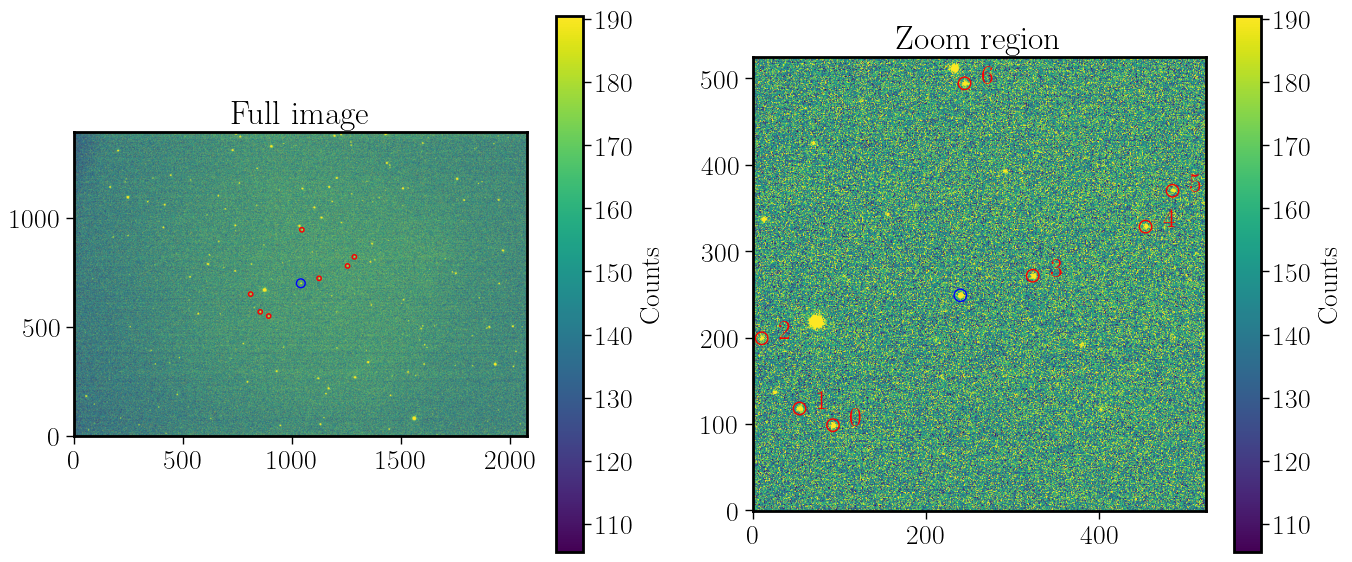

In [86]:

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im0 = axes[0].imshow(data, origin='lower', 
                     vmin=np.median(data) - np.std(data), 
                     vmax= np.median(data) + np.std(data))
axes[0].set_title("Full image")

if sources is not None and len(sources) > 0:
    axes[0].scatter(
        sources['xcentroid'] + 800,
        sources['ycentroid'] + 450,
        s=10,
        facecolors='none',
        edgecolors='red'
    )

axes[0].scatter(
    position_occulted[0][0] + 800,
    position_occulted[0][1] + 450,
    s=40,
    facecolors='none',
    edgecolors='blue'
)

fig.colorbar(im0, ax=axes[0], label='Counts')

im1 = axes[1].imshow(reduction, origin='lower', 
                     vmin=np.median(data) - np.std(data), 
                     vmax=  np.median(data) + np.std(data))
axes[1].set_title("Zoom region")

if sources is not None and len(sources) > 0:
    axes[1].scatter(
        sources['xcentroid'],
        sources['ycentroid'],
        s=80,
        facecolors='none',
        edgecolors='red'
    )

axes[1].scatter(
    position_occulted[0][0],
    position_occulted[0][1],
    s=80,
    facecolors='none',
    edgecolors='blue'
)

for i, (x, y) in enumerate(zip(sources['xcentroid'], sources['ycentroid'])):
    axes[1].text(x + 20, y, str(i), color='red', fontsize=20)

fig.colorbar(im1, ax=axes[1], label='Counts')

plt.tight_layout()
plt.show()

Once we have selected the stars for differential photometry, it is necessary to define the aperture from which we will extract the stellar flux. Theoretically, any radius could be used as long as it encloses only one star, provided we subtract the background based on the chosen area. However, a larger aperture increases the measurement error; furthermore, since the images have not been corrected with FLAT and BIAS frames, a larger area introduces greater uncertainty in the counts.

For this reason, we will set the aperture as close as possible to the star's profile. To achieve this, we will calculate the FWHM (Full Width at Half Maximum) of the star and set the aperture radius to 1.25 times the FWHM. The FWHM selection process and the visual representation of both the aperture and the FWHM for the target stars are shown in the code below:

In [113]:
with fits.open(os.path.join(root,'Biennor_00001.fits')) as hdul:
    target = hdul[0].data

data = target

fwhm = fit_fwhm(
    data=reduction,
    xypos=positions,
    fit_shape=(3, 3)
)

circulus = []
annulus = []
for  pos, fh in zip(positions, fwhm):

    r = fh*1.1
    dr = 6
    circulus.append(CircularAperture(pos, r = fh*1.1))
    annulus.append(CircularAnnulus(pos, r_in=r+2, r_out=r+dr))

fwhm2 = fit_fwhm(
    data=reduction,
    xypos=position_occulted,
    fit_shape=(3, 3)
)

occulted_circulus = CircularAperture(position_occulted, r = fwhm2[0]*1.1)
occulted_annulus = CircularAnnulus(position_occulted, r_in=fwhm2[0]*1.1 +2, r_out=fwhm2[0]*1.1 + 6)


In [117]:
full = []

for dirpath, dirnames, filenames in os.walk(root):
    filenames = sorted(filenames)

filenames = filenames[1:]

for file in filenames:
    with fits.open(os.path.join(root, file)) as hdul:
        source = hdul[0].data

fwhm2 = fit_fwhm(
    data=reduction,
    xypos=position_occulted,
    fit_shape=(3, 3)
)

full.append(fwhm2)

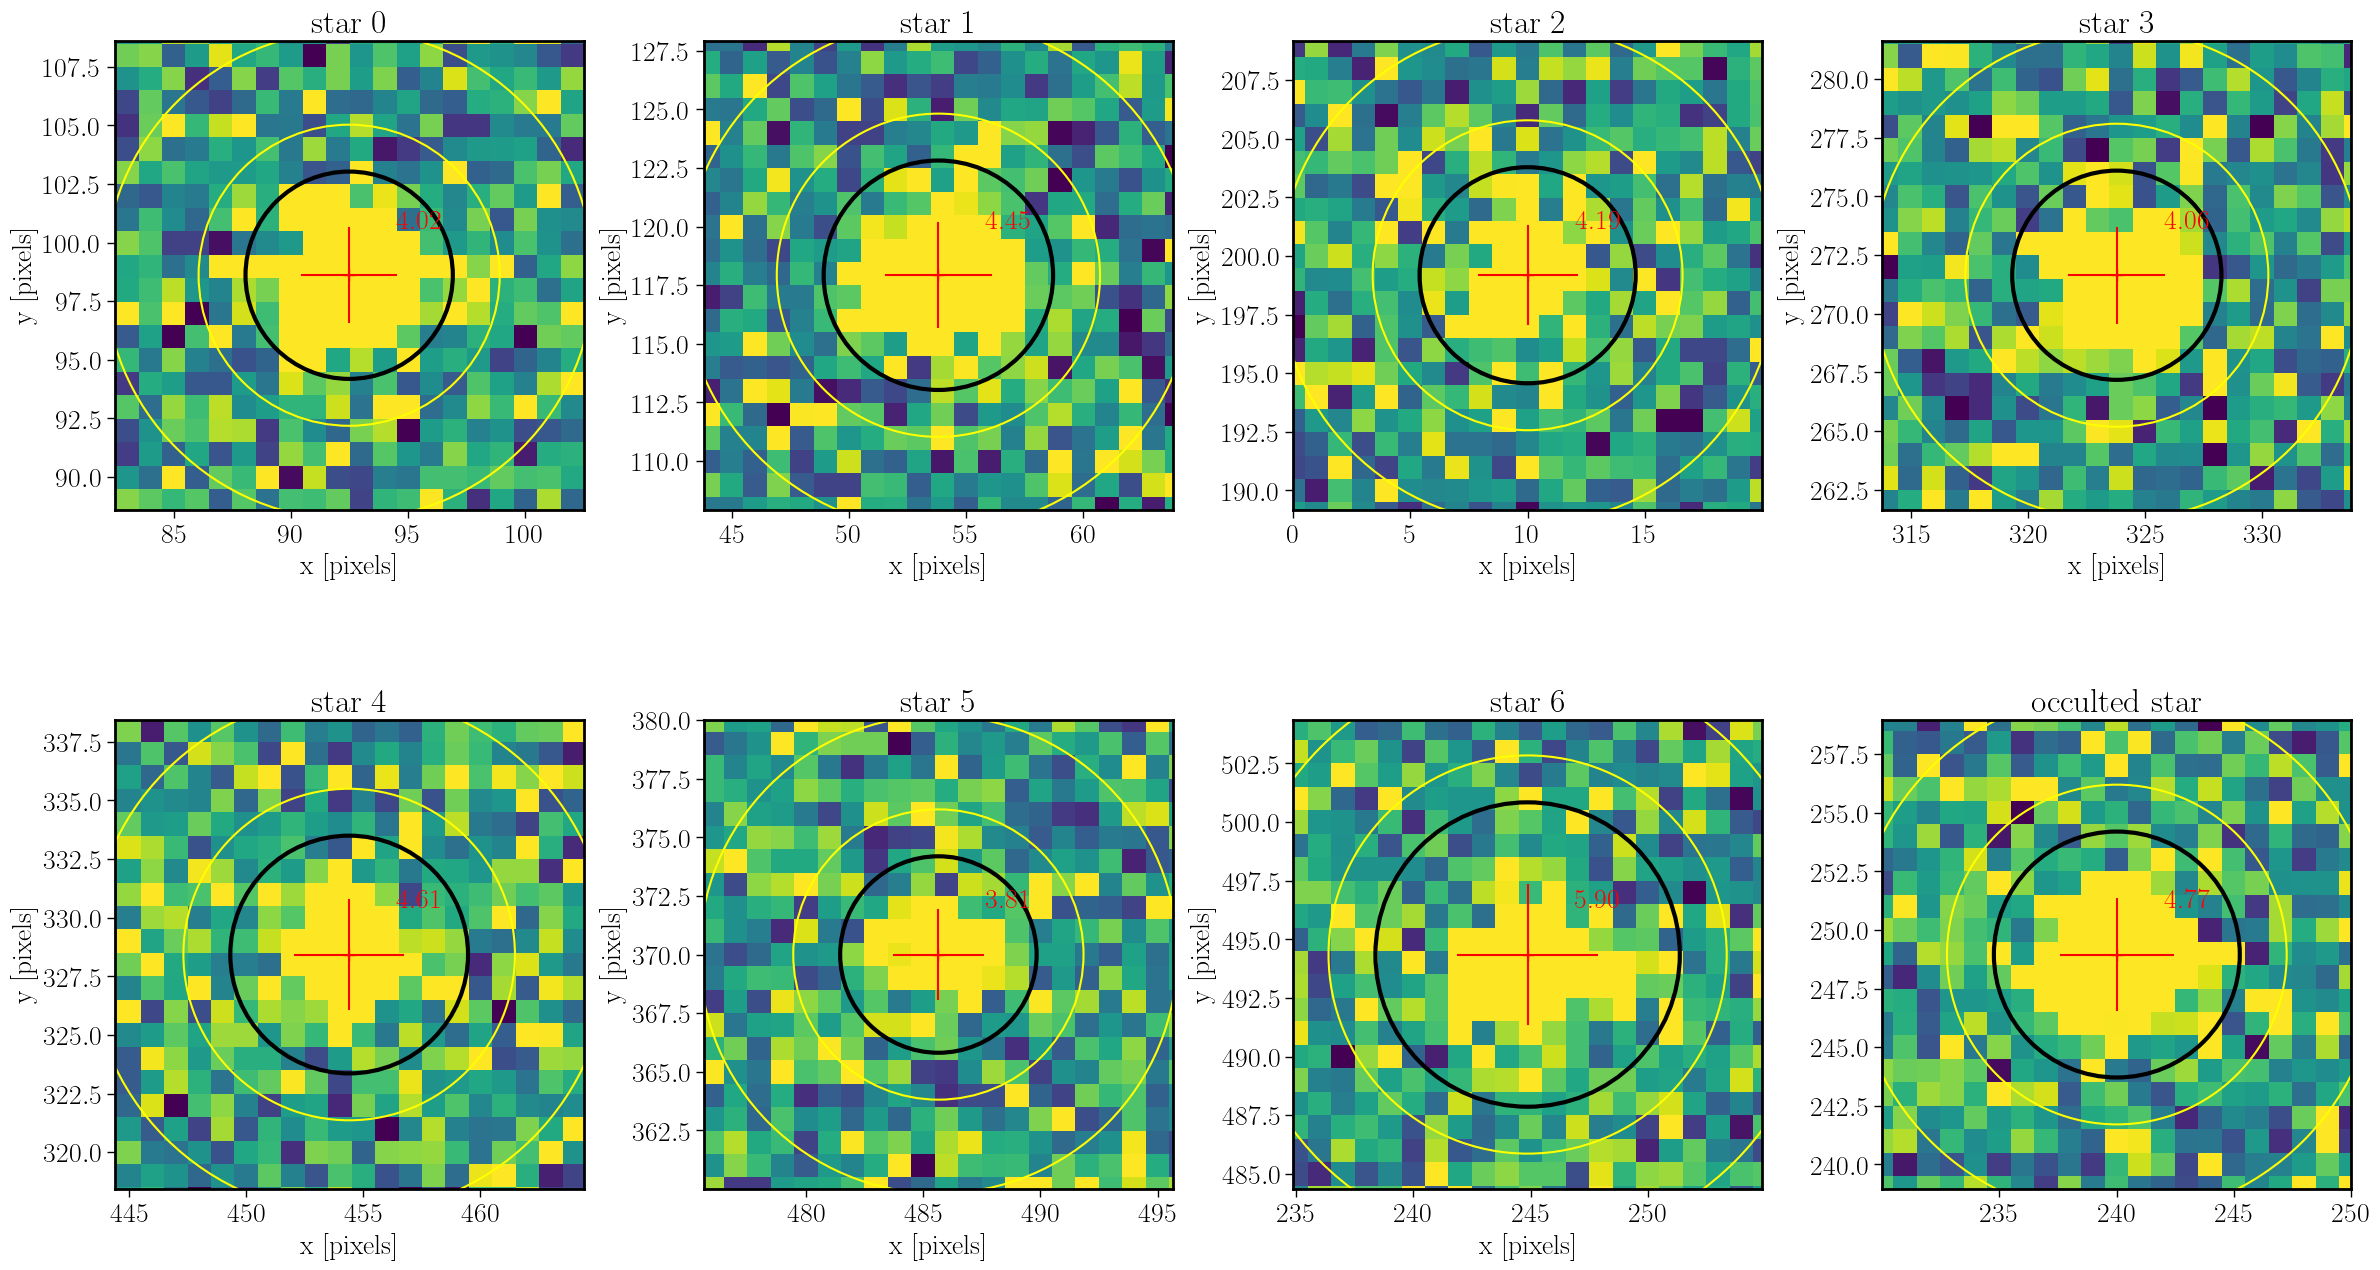

In [115]:
with fits.open(os.path.join(root,'Biennor_00001.fits')) as hdul:
    target = hdul[0].data

fig, axes = plt.subplots(2, 4, figsize=(24, 14))
axes = axes.flatten()

data = target
reduction = data[450:975, 800:1325]

vmin = np.median(data) - np.std(data)
vmax = np.median(data) + np.std(data)

for i, (ax, pos, fw, circ, an) in enumerate(zip(axes, positions, fwhm, circulus, annulus)):

    x, y = pos

    windowx = (x - 10, x + 10)
    windowy = (y - 10, y + 10)

    ax.imshow(reduction, origin='lower', vmin=vmin, vmax=vmax)

    ax.set_xlim(windowx)
    ax.set_ylim(windowy)

    ax.set_title(f'star {i}')
    ax.set_xlabel('x [pixels]')
    ax.set_ylabel('y [pixels]')

    ax.plot(x, y, 'r+', markersize=8)

    half = fw / 2
    ax.plot([x - half, x + half], [y, y], 'r-')
    ax.plot([x, x], [y - half, y + half], 'r-')

    circ.plot(ax=ax, color='black', lw=3)
    an.plot(ax=ax, color='yellow', lw=1.5)

    ax.text(x + 2, y + 2, f"{fw:.2f}", color='red', fontsize=20)

ax = axes[-1]

x_occ = position_occulted[0][0]
y_occ = position_occulted[0][1] 

half_occ = fwhm2[0] / 2

ax.imshow(reduction, origin='lower', vmin=vmin, vmax=vmax)
ax.set_title("occulted star")

ax.set_xlim((x_occ - 10, x_occ + 10))
ax.set_ylim((y_occ - 10, y_occ + 10))

ax.plot(x_occ, y_occ, 'r+', markersize=8)

ax.plot([x_occ - half_occ, x_occ + half_occ], [y_occ, y_occ], 'r-')
ax.plot([x_occ, x_occ], [y_occ - half_occ, y_occ + half_occ], 'r-')


occulted_circulus.plot(ax=ax, color='black', lw=3)
occulted_annulus.plot(ax=ax, color='yellow', lw=1.5)

ax.text(x_occ + 2, y_occ + 2, f"{fwhm2[0]:.2f}", color='red', fontsize=20)

plt.tight_layout()
plt.show()

Once we have determined the radii and the corresponding annuli for each star based on their FWHM, we must calculate the corrected flux for each star and create a **synthetic star** based on the statistics of the previously studied objects. The following code demonstrates how to extract the required information for each star.

 **Note:** Since `circulus` and `annulus` are lists, and `ApertureStats` does not support this data type directly, we will iterate through the elements of each list to access the information.

In [66]:
flux_matrix = []
synthetic_star = []

for observation in images_2:

    flux = []

    for cir, an in zip(circulus, annulus):

        ap_stats = ApertureStats(observation, cir)
        flux_ap = ap_stats.sum

        bkg_stats = ApertureStats(observation, an)
        bkg_median = bkg_stats.median

        area = cir.area

        flux_corr = flux_ap - bkg_median * area

        flux.append(flux_corr)

    
    synthetic_star.append(np.median(flux))

    flux_matrix.append(flux)

flux_matrix = np.array(flux_matrix).T
synthetic_star = np.array(synthetic_star)

cols = [f'image_{i}' for i in range(len(flux_matrix[0]))]

df_flux = pd.DataFrame(flux_matrix, columns=cols)

f_norm = df_flux.div(df_flux.median(axis=1), axis=0)


In [67]:
occulted_flux = []

for observation in images_2:

    ap_stats = ApertureStats(observation, occulted_circulus)
    flux_ap = ap_stats.sum

    bkg_stats = ApertureStats(observation, occulted_annulus)
    bkg_median = bkg_stats.median

    area = occulted_circulus.area

    flux_corr = flux_ap - bkg_median * area

    occulted_flux.append(flux_corr)

occulted_flux = np.array(occulted_flux/np.median(occulted_flux))

Once all the flux data is structured, it is necessary to retrieve the timing information for each frame captured by the telescope. Time is typically represented in seconds since midnight of the observation date, which is a standard unit in stellar occultations by trans-Neptunian objects (TNOs). The following code illustrates the process of extracting this information, completing the dataset required for scientific analysis.

In [68]:
for dirpath, dirnames, filenames in os.walk(root):
    filenames = sorted(filenames)
    filenames = filenames[1:]

times = []

for f in filenames:
    with fits.open(os.path.join(root,f)) as hdul:
        header = hdul[0].header
        
        t = Time(header['DATE-AVG'], format='isot', scale='utc', precision=7)
        times.append(t)

times = Time(times)

t0_midnight = Time(times[0].isot.split('T')[0] + 'T00:00:00', format='isot', scale='utc')

time_sec = (times - t0_midnight).sec

## Light Curve of the occulted star Representation

Once all the data has been properly organized, the light curve of the star must be plotted.

First, to determine whether an occultation has occurred, we must plot the light curves of all the stars and identify a statistically significant drop in the flux of the target star. However, much like the reference stars, the target star will still exhibit statistical fluctuations caused by the Earth's atmosphere. For this reason, we must select the reference flux that most closely matches that of the occulted star. By dividing the flux of the occulted star by this reference flux, we obtain a normalized light curve, effectively removing the atmospheric fluctuations.

The code below demonstrates a clear occultation in the target star relative to the reference stars. Nevertheless, to quantify which model curve best fits the observed data, we must define a metric for a rigorous comparison, as visual inspection is prone to error.

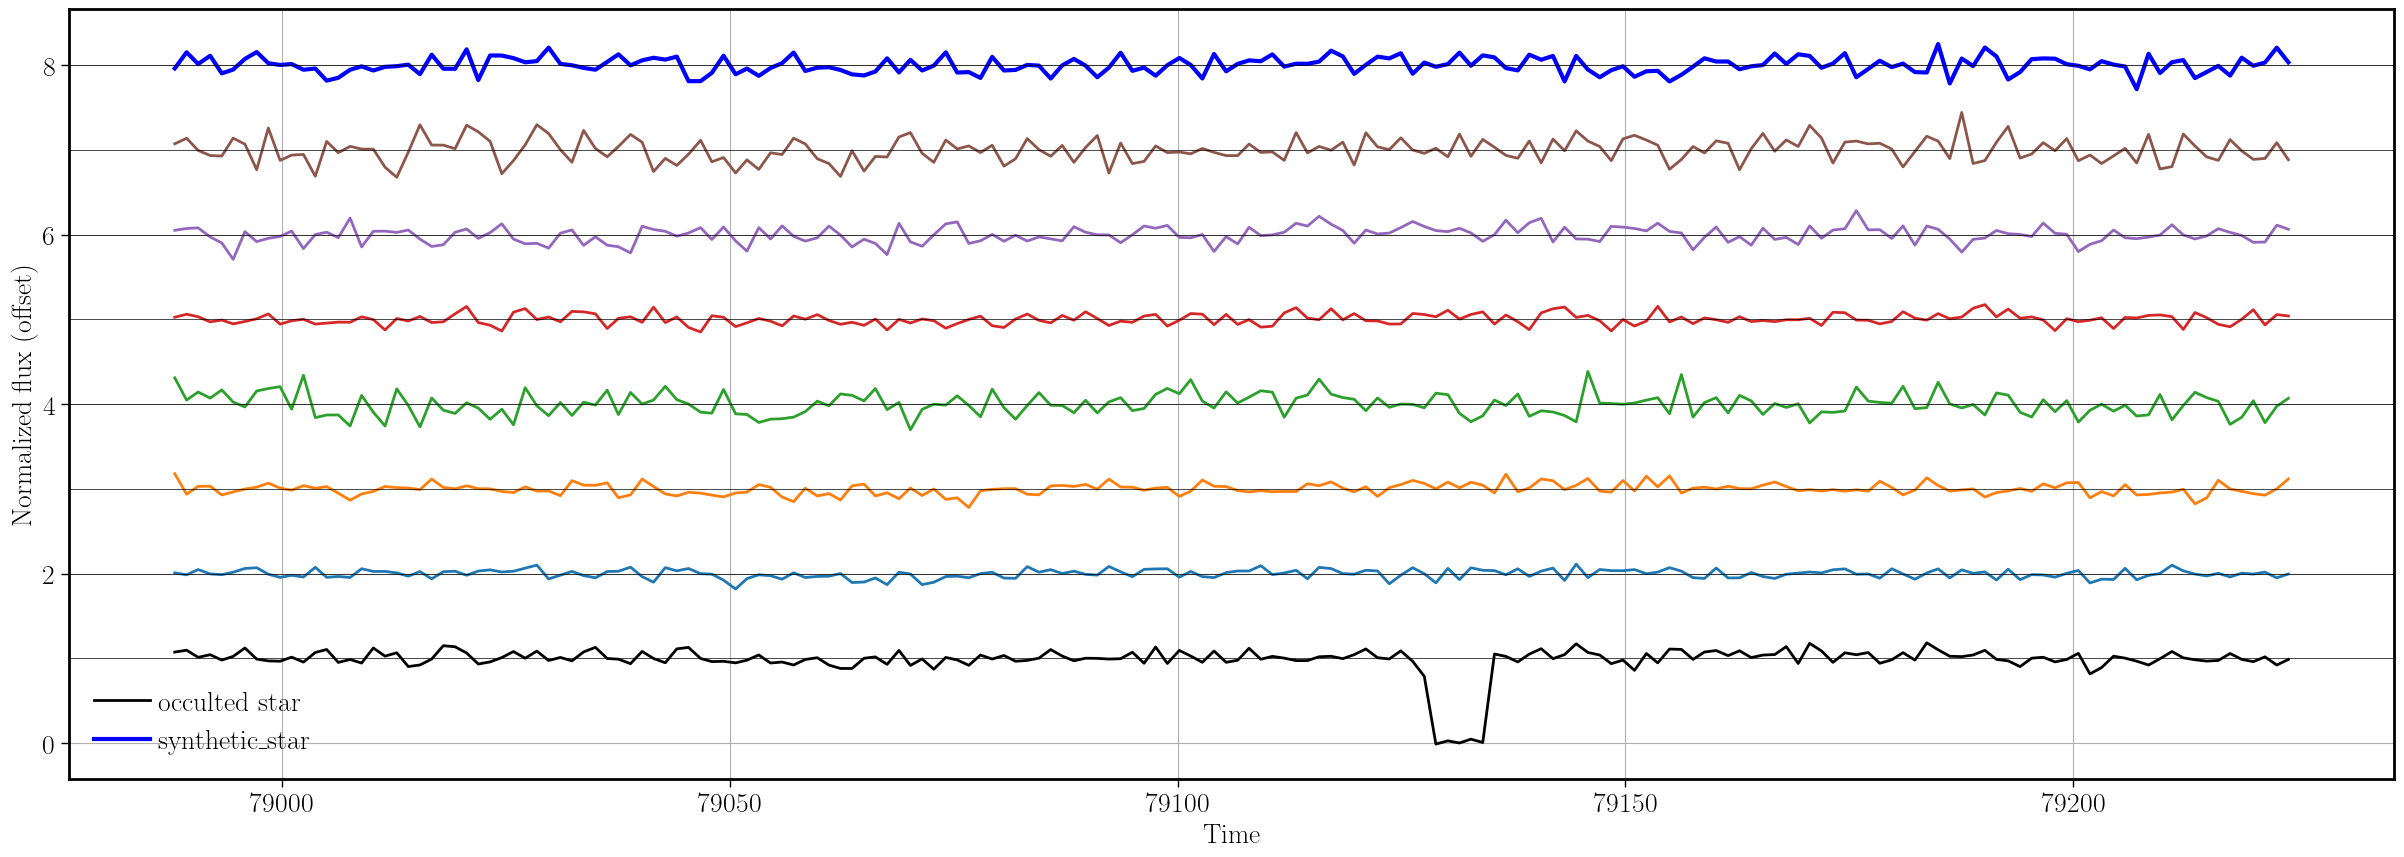

In [69]:
plt.figure(figsize=(30, 10))

plt.plot(time_sec, occulted_flux,
         color='black', linewidth=2, label='occulted star')

#plt.scatter(time_sec, occulted_Star.values,
#            edgecolors='black', color='black', alpha=0.7)

for idx, row in f_norm.iterrows():

    offset = idx + 1

    if idx == 6:

        plt.plot(time_sec, row.values + offset,
                 linewidth=3, color='blue', label='synthetic_star')

    else:


        flux = row.values + offset

        plt.plot(time_sec, flux, linewidth=2)

        #plt.scatter(time_sec, flux,
        #            edgecolors='black', alpha=0.6)

for y in range(1, 9):
    plt.axhline(y, color='black', linewidth=0.5, alpha=1)

plt.xlabel('Time')
plt.ylabel('Normalized flux (offset)')
plt.grid()
plt.legend()

We present four distinct metrics to determine which of the seven candidate curves most closely resembles the curve of the occulted star.

---

### 1. Pearson Correlation Coefficient
The first method involves calculating the **Pearson Correlation Coefficient**, which allows us to estimate the correlation between curves (i.e., how similar their shapes are). 

* The coefficient ranges from **-1 to 1**.
* **1** implies a perfect positive correlation.
* **-1** implies a perfect negative correlation.
* **0** implies no relationship between the curves.

### 2. Point-by-Point Comparison
The second method compares both curves point-by-point to identify which curve **minimizes the distance** to the occulted star's curve.

### 3. First Derivative Analysis
The third approach involves the definition of the **derivative**. We study the derivative for each of the vectors containing the stellar information (including the occulted star) using the following formula:

$$\frac{dv_i}{dt} \approx \frac{v_{i+1} - v_i}{\Delta t}$$

Once the derivative of each vector is obtained, we return to the logic of the second method: calculating the vector of derivatives that **minimizes the distances** between the curves.

### 4. Second Derivative Analysis
The final option is to apply the **second derivative**. This follows the same methodology as the third approach but utilizes the following expression:

$$\frac{d^2 v}{dt^2}\bigg|_{t_i} \approx \frac{v_{i+1} - 2v_i + v_{i-1}}{(\Delta t)^2}$$

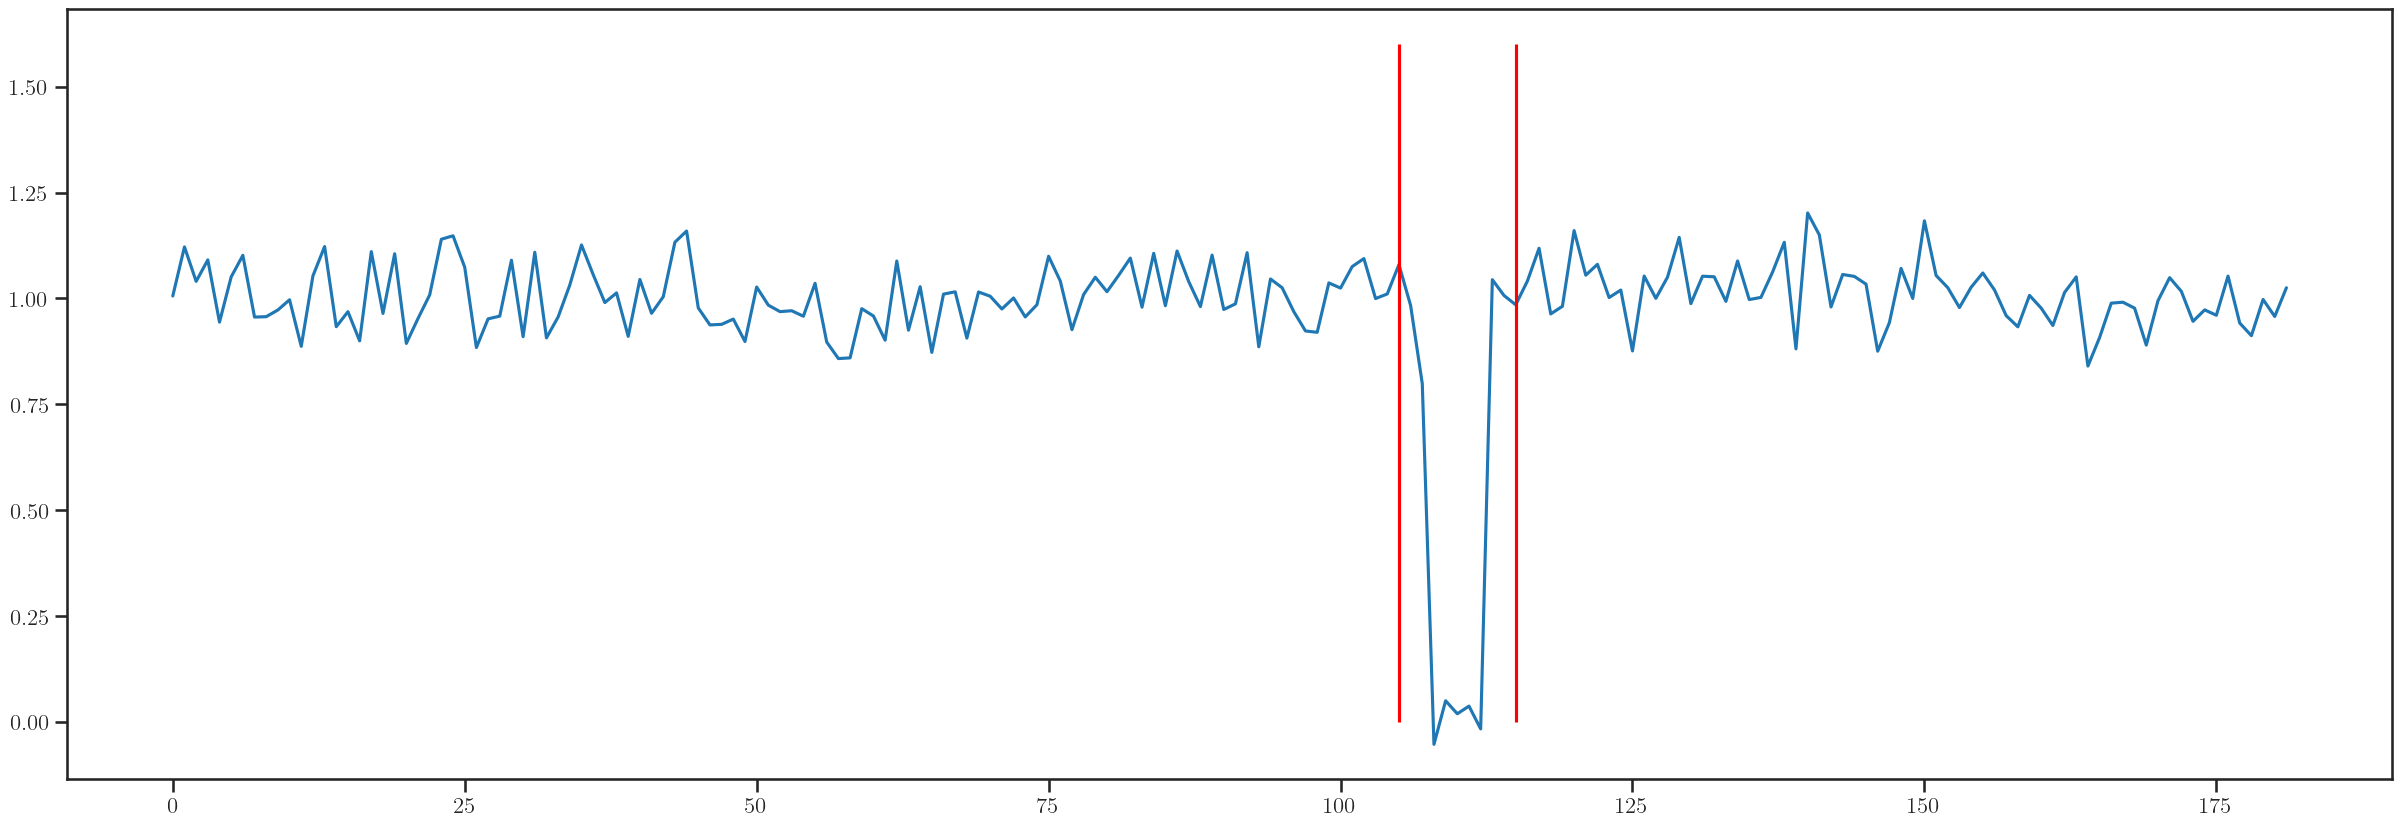

In [51]:
plt.figure(figsize=(30, 10))
plt.plot( occulted_flux,)
plt.vlines(105, 0, 1.6, color = 'red')
plt.vlines(115, 0, 1.6, color = 'red')

In [38]:
target = np.concatenate([
    occulted_flux[0:105],
    occulted_flux[105:]
]).ravel()

similarities = []

for idx, row in f_norm.iterrows():
    
    star = np.concatenate([
    row.values[0:105],
    row.values[105:]
    ]).ravel()
    
    corr = np.corrcoef(target, star)[0, 1]
    similarities.append((idx, corr))

similarities.sort(key=lambda x: x[1], reverse=True)

print(similarities)

[(0, np.float64(0.09951561898060036)), (2, np.float64(0.04124036076151758)), (4, np.float64(0.01183685080644842)), (5, np.float64(0.0022538555298521378)), (1, np.float64(-0.030426516768541786)), (6, np.float64(-0.05889963036025506)), (3, np.float64(-0.10472436745758847))]


In [39]:
similarities = []

for idx, row in f_norm.iterrows():

    star = np.concatenate([
    row.values[0:105],
    row.values[105:]
    ]).ravel()
    
    dist = np.sum((target - star)**2)
    
    similarities.append((idx, dist))

similarities.sort(key=lambda x: x[1])

print(similarities)

[(0, np.float64(5.855715966725821)), (1, np.float64(6.617099933546044)), (3, np.float64(6.936275443022327)), (4, np.float64(7.254938025309263)), (6, np.float64(7.820168961364324)), (2, np.float64(8.485113481295773)), (5, np.float64(9.198578176990154))]


In [40]:
deriv_target = np.gradient(target)

similarities = []

for idx, row in f_norm.iterrows():

    star = np.concatenate([
    row.values[0:105],
    row.values[105:]
    ]).ravel()
    
    dist = np.sum((deriv_target - np.gradient(star))**2)
    
    similarities.append((idx, dist))

similarities.sort(key=lambda x: x[1])

print(similarities)

[(0, np.float64(1.3739114919720177)), (1, np.float64(1.4802497283155043)), (4, np.float64(1.6289533919415193)), (3, np.float64(1.8202270072393558)), (6, np.float64(2.1739230751921346)), (2, np.float64(2.7501479294246804)), (5, np.float64(3.2553816619081344))]


In [41]:
deriv_target = np.gradient(target)

similarities = []

for idx, row in f_norm.iterrows():

    star = np.concatenate([
    row.values[0:105],
    row.values[105:]
    ]).ravel()

    deriv_star = np.gradient(star)
    
    corr = np.corrcoef(deriv_target, deriv_star)[0, 1]
    similarities.append((idx, corr))

similarities.sort(key=lambda x: x[1], reverse=True)

print(similarities)

[(4, np.float64(0.2032511545783416)), (1, np.float64(0.1518200693094525)), (0, np.float64(0.1319544767986075)), (2, np.float64(-0.0005148855193984149)), (6, np.float64(-0.0008227585912318927)), (5, np.float64(-0.020946792096494974)), (3, np.float64(-0.09584044602680825))]


In [42]:
deriv2_target = np.gradient(np.gradient(target))

similarities = []

for idx, row in f_norm.iterrows():

    star = np.concatenate([
        row.values[0:105],
        row.values[105:]
    ]).ravel()

    # Segunda derivada de cada estrella
    deriv2_star = np.gradient(np.gradient(star))
    
    corr = np.corrcoef(deriv2_target, deriv2_star)[0, 1]
    similarities.append((idx, corr))

similarities.sort(key=lambda x: x[1], reverse=True)

print(similarities)

[(4, np.float64(0.25419965822638596)), (1, np.float64(0.22049385514779787)), (0, np.float64(0.17581305202728617)), (6, np.float64(0.002886266060107507)), (2, np.float64(-0.027557230263954225)), (5, np.float64(-0.031204306785146498)), (3, np.float64(-0.093398181347438))]


The methods yield different results: while the first two, which aim to obtain a robust metric based on the distance between points, show a better fit with **Curve 0**, the metrics analyzing the derivatives reflect that the best curve—meaning the one with behavior most similar to the occulted star—is **Curve 4**. (For a more comprehensive analysis of this topic, see Appendix 3).

Since all methods are currently considered equally valid, we will plot all light curves by dividing the occulted star's curve by the others to determine which provides the best result. The results are shown below:

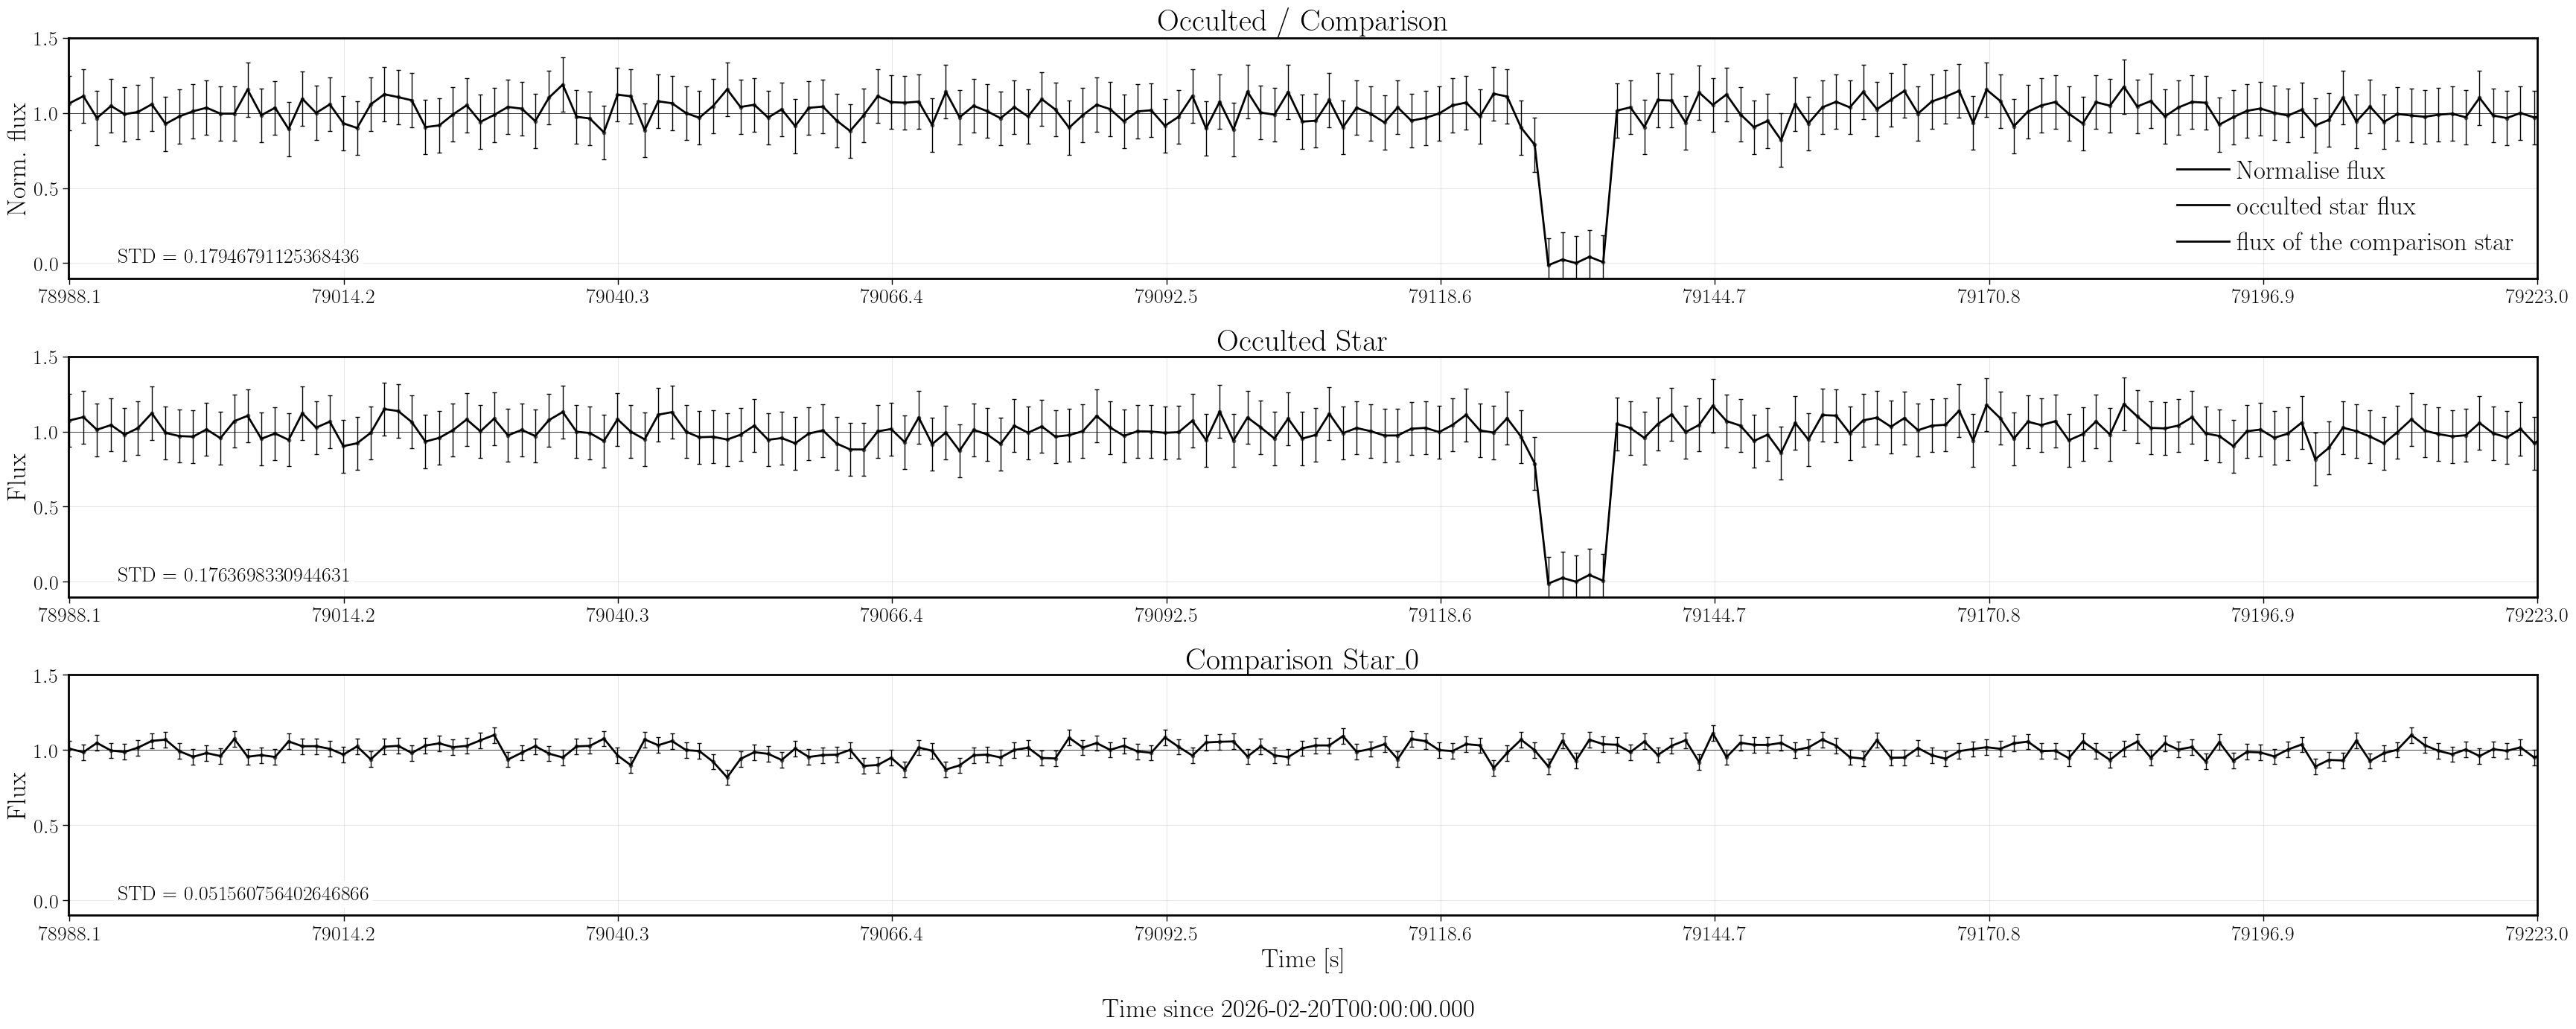

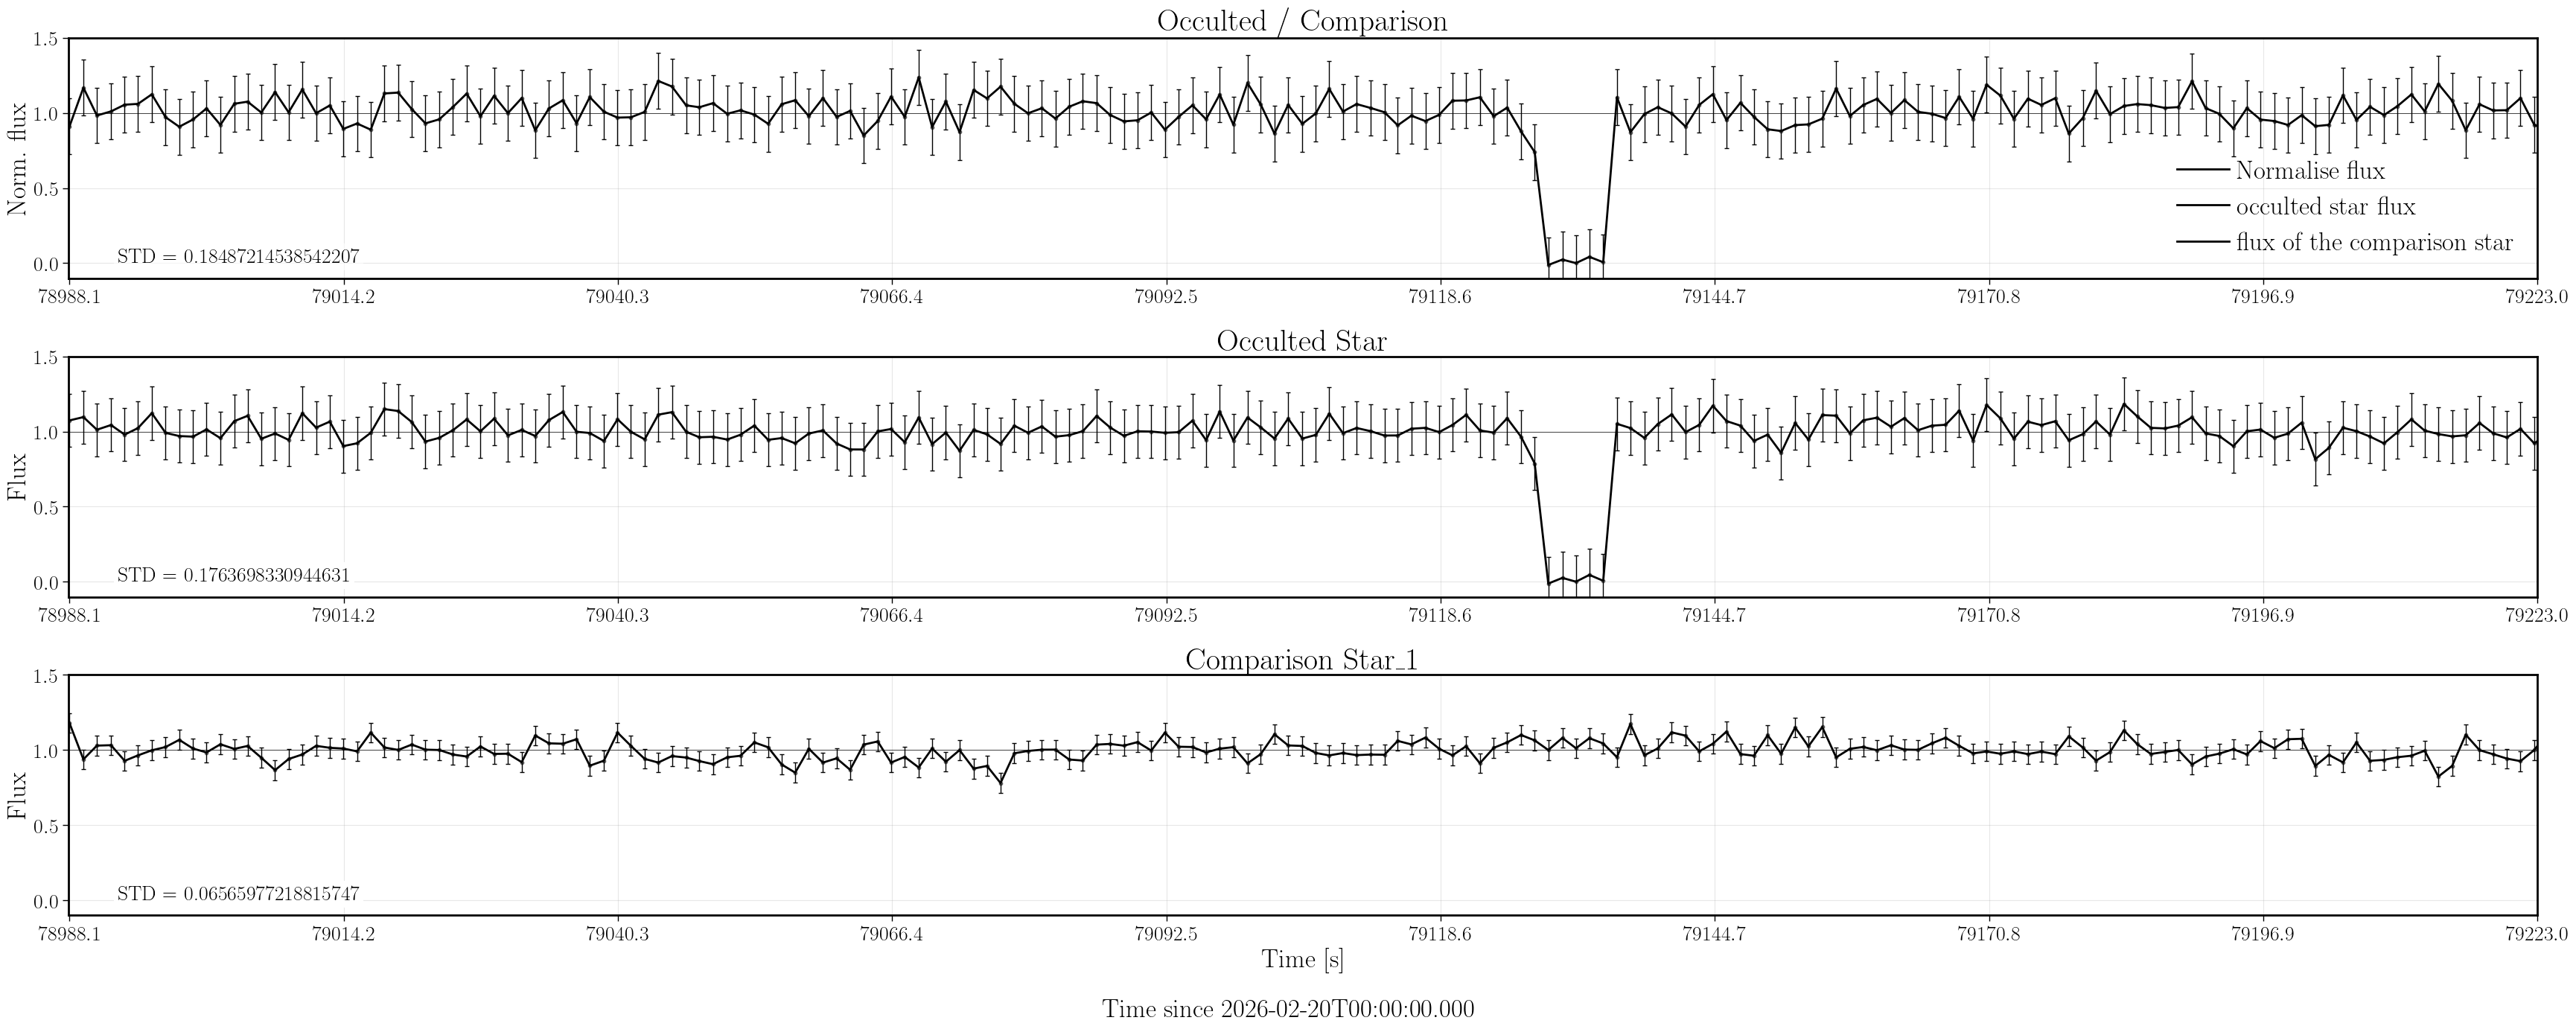

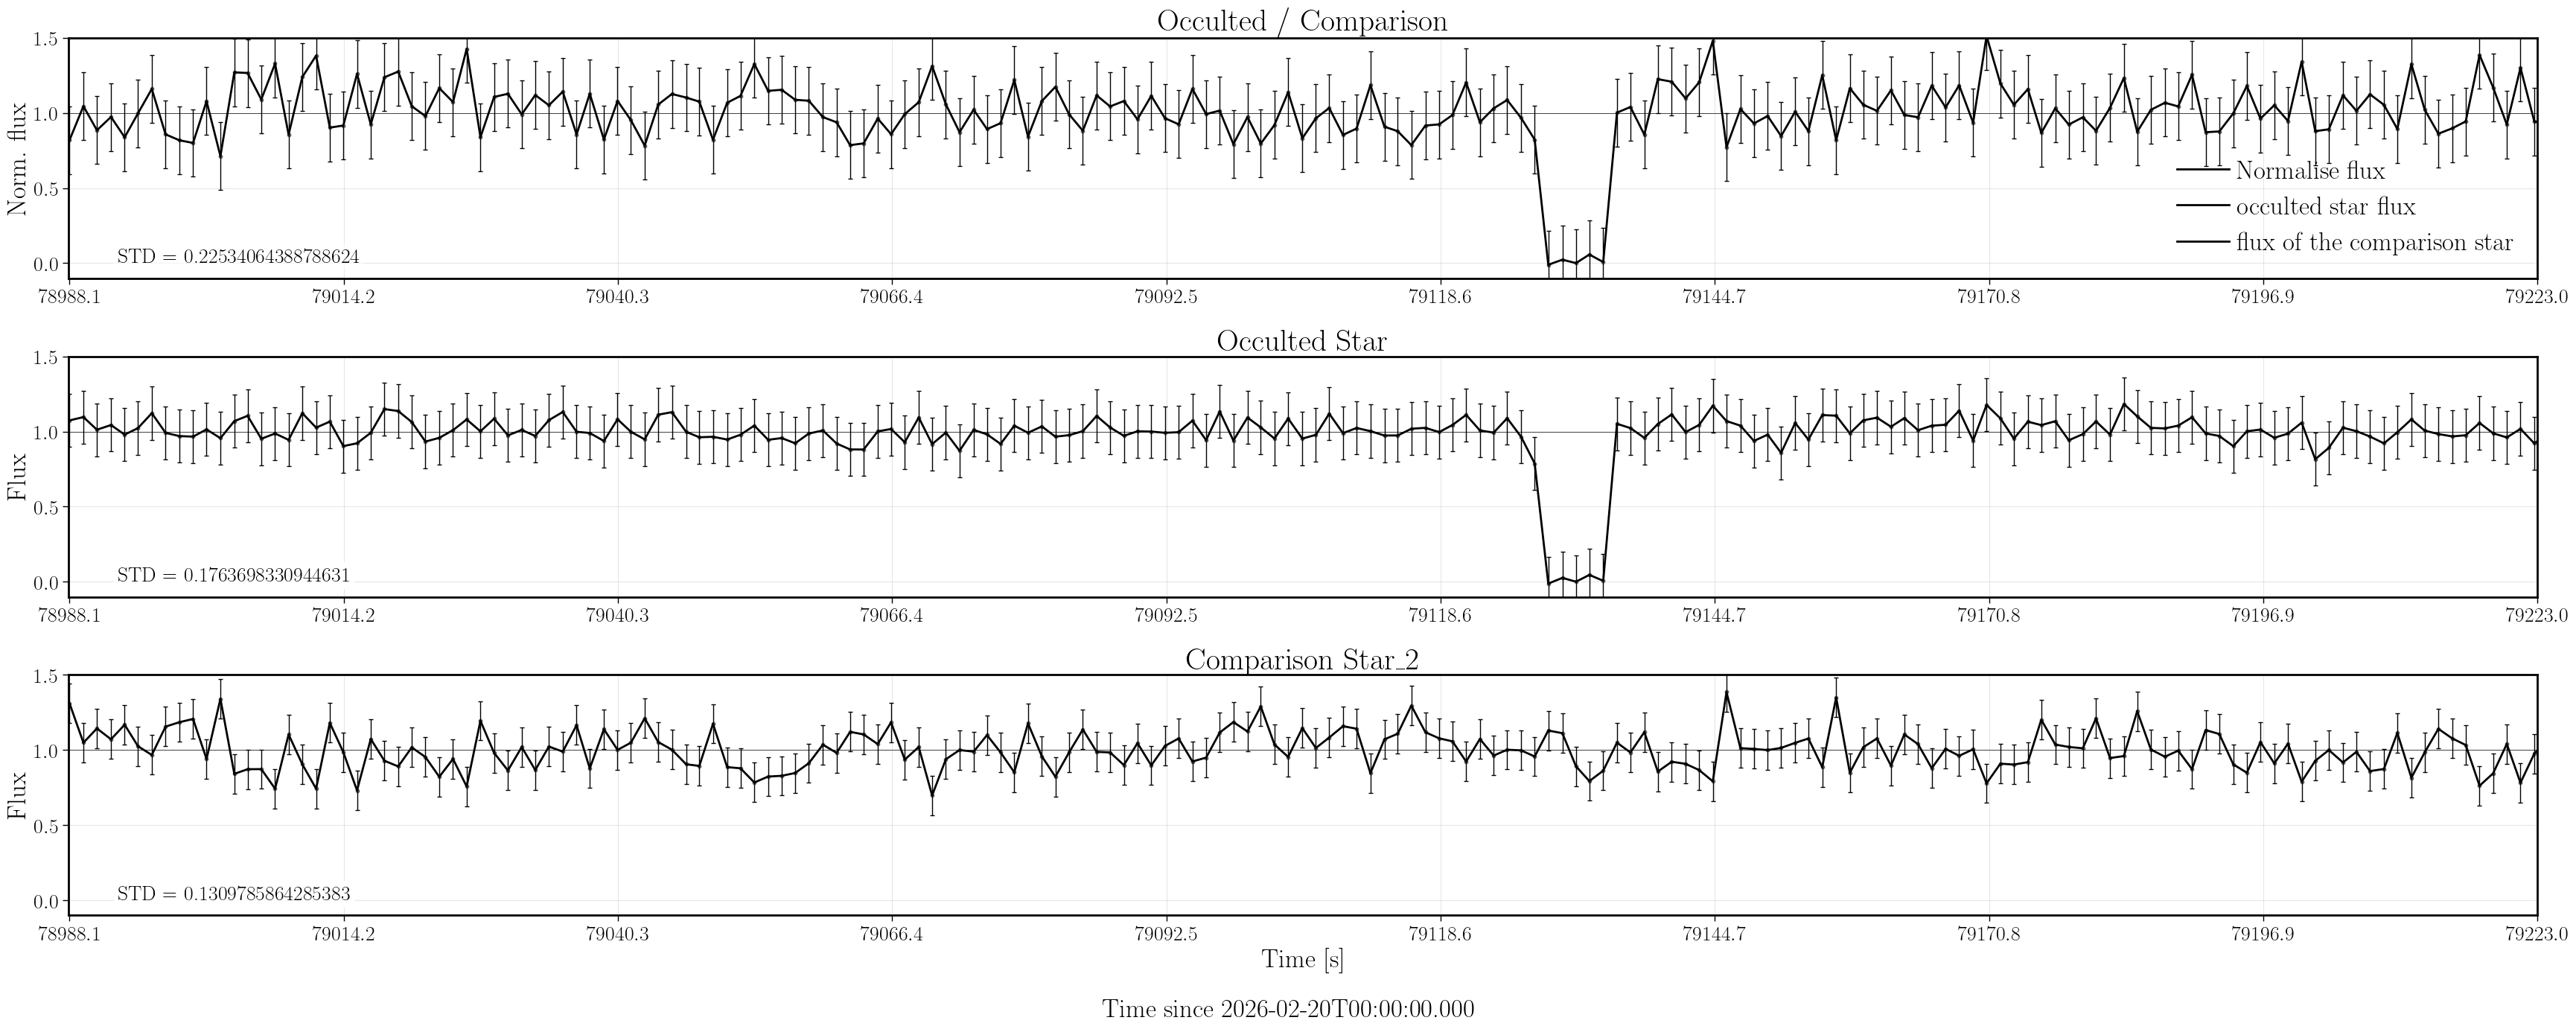

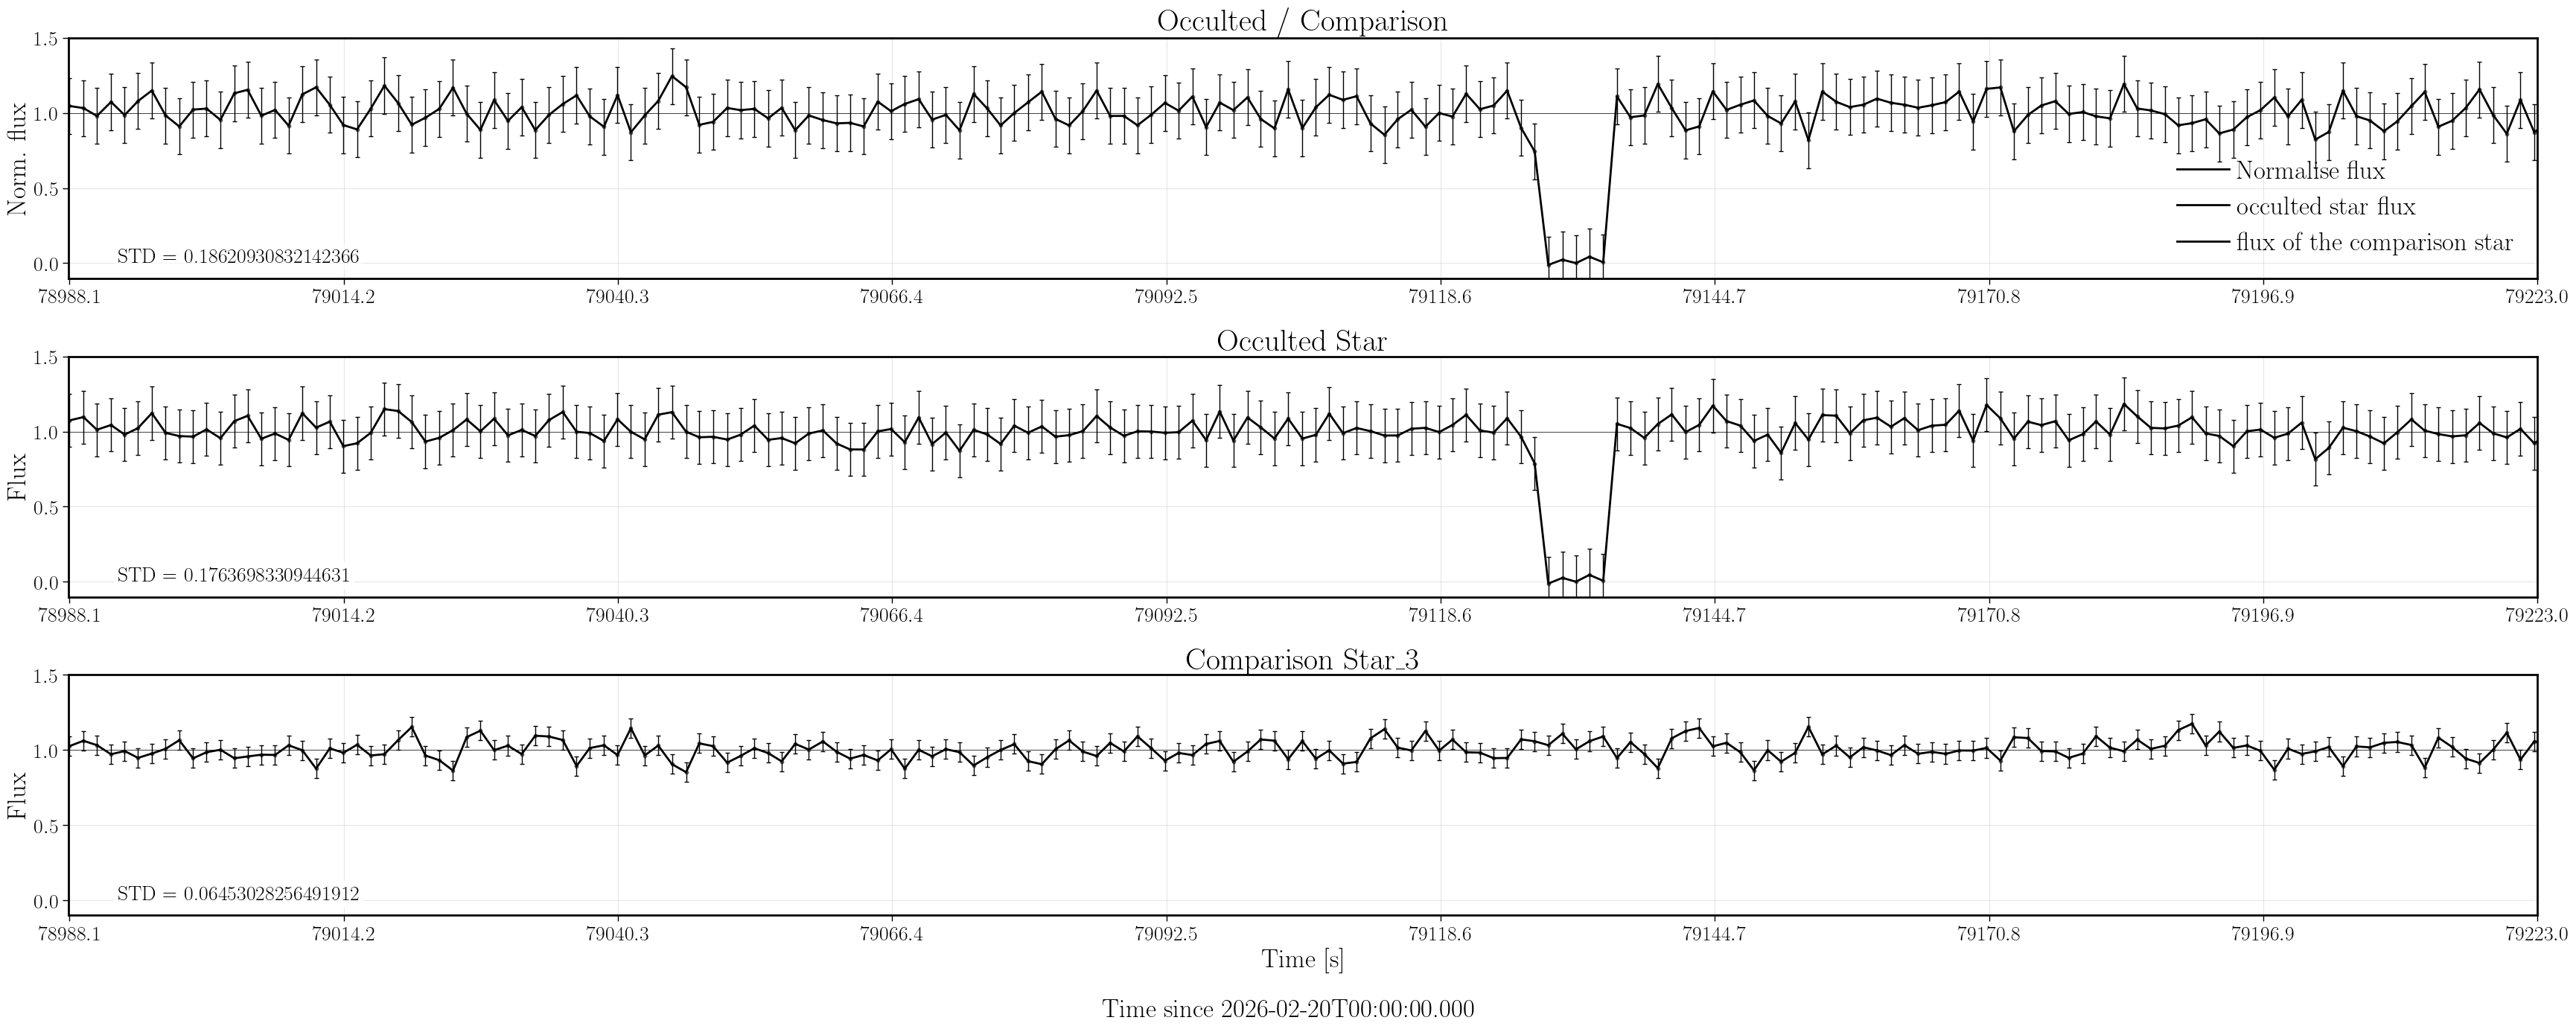

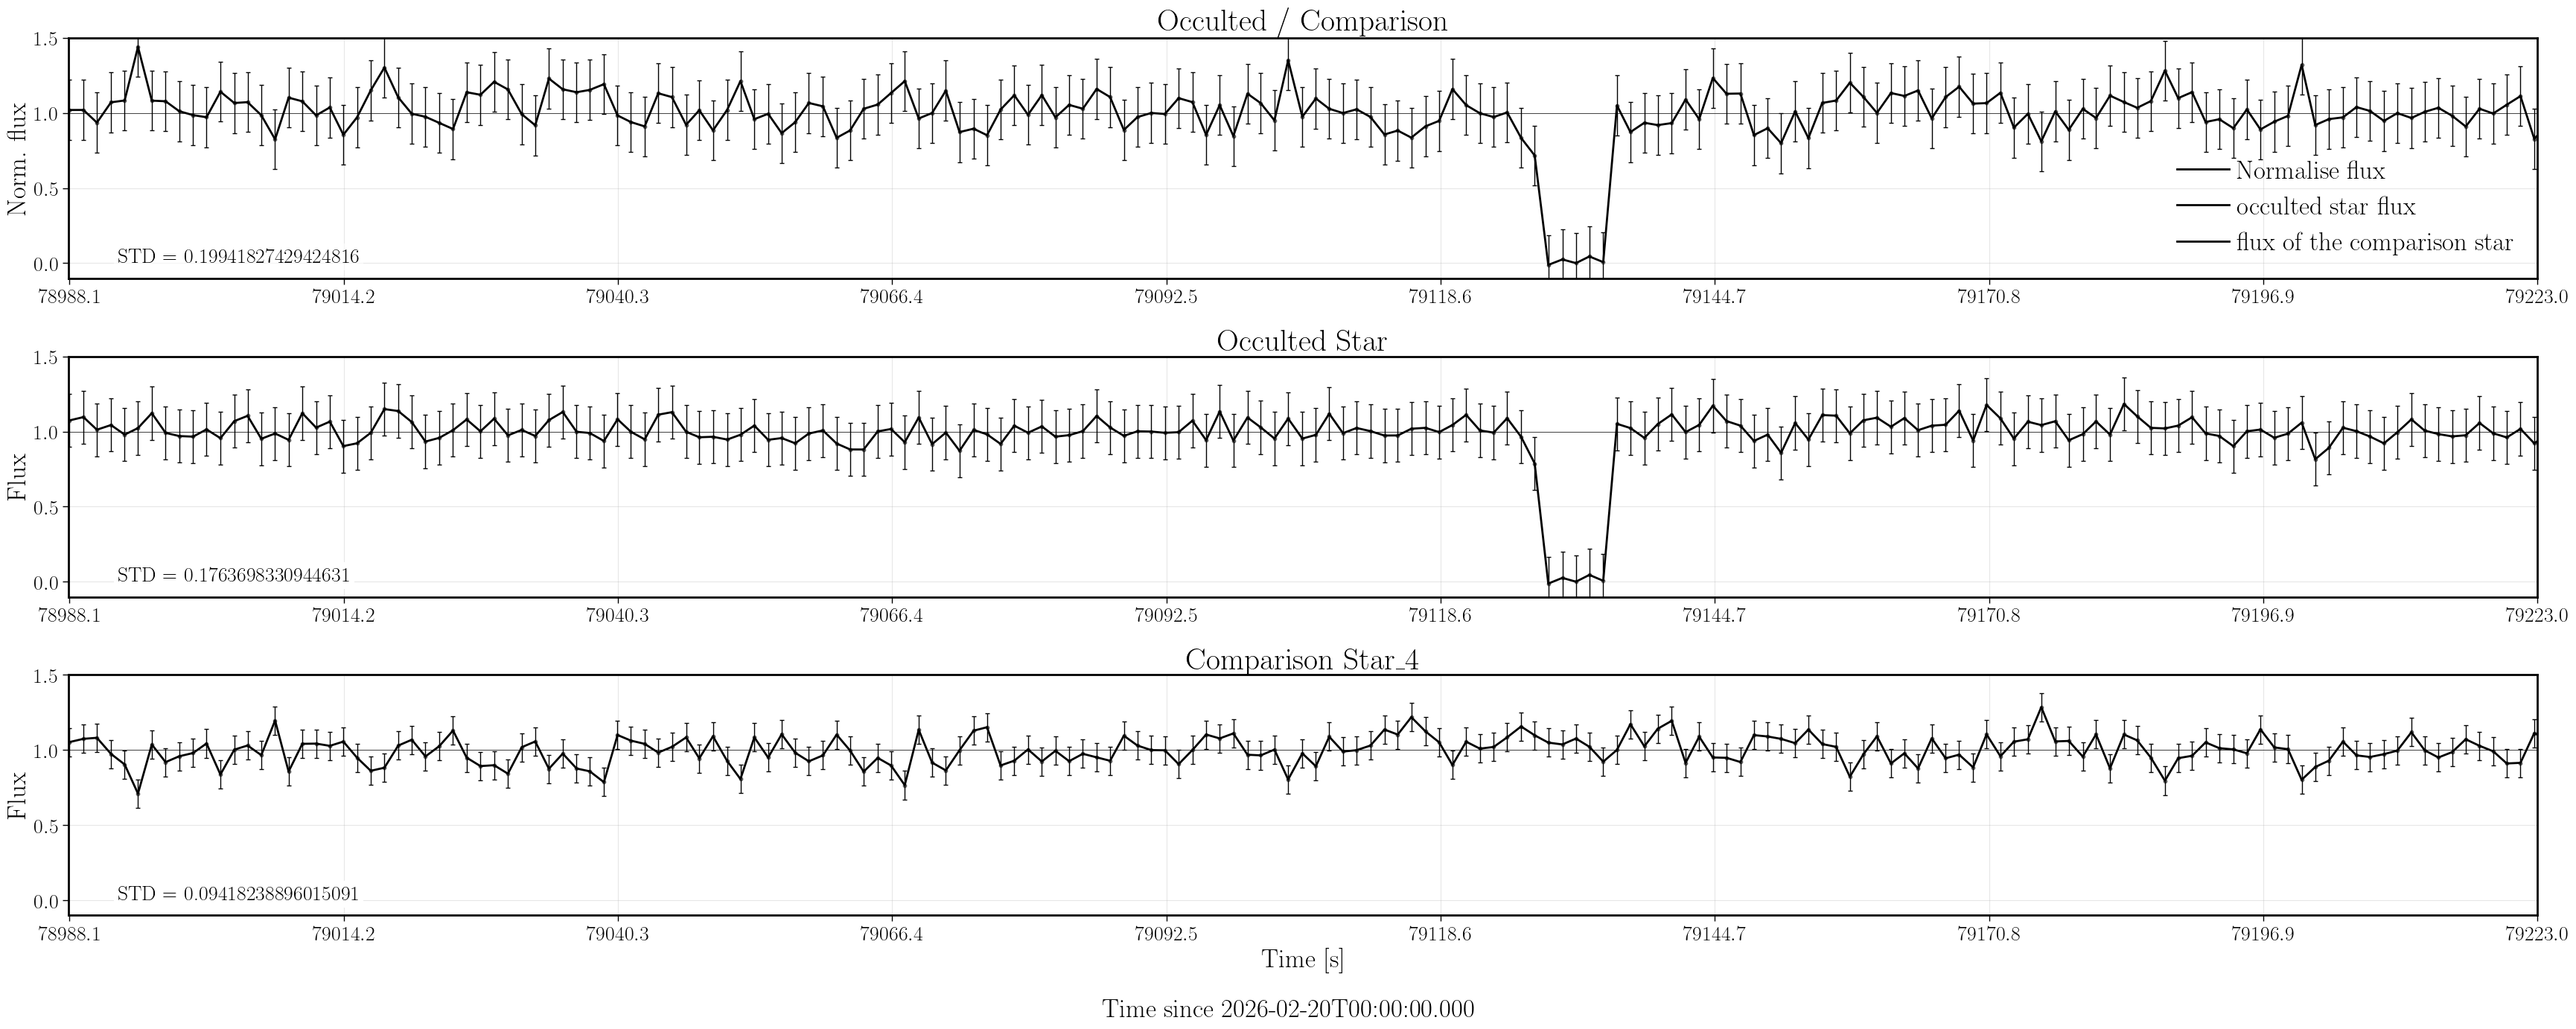

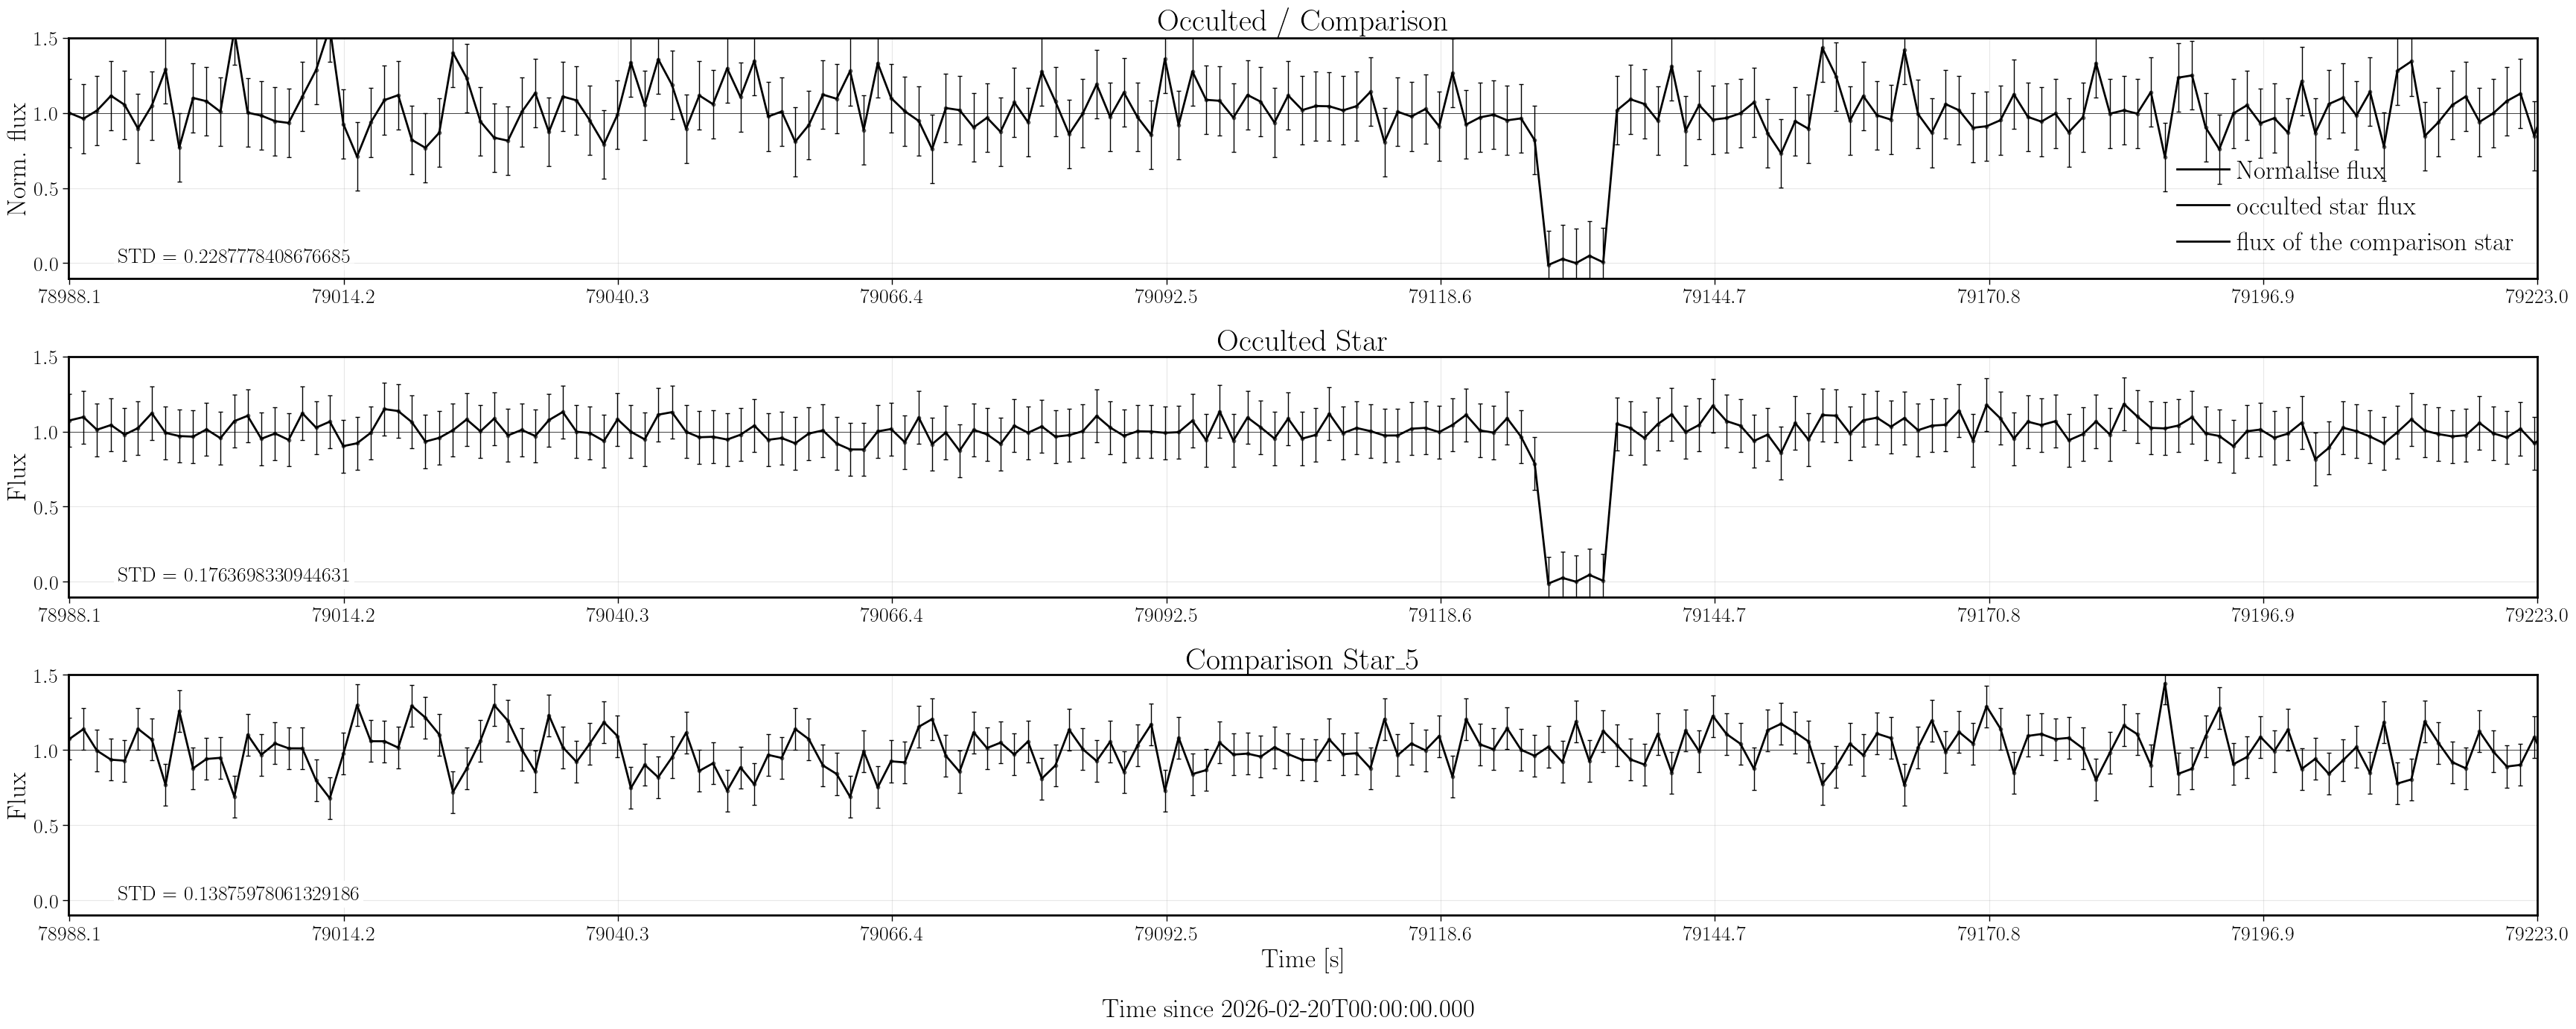

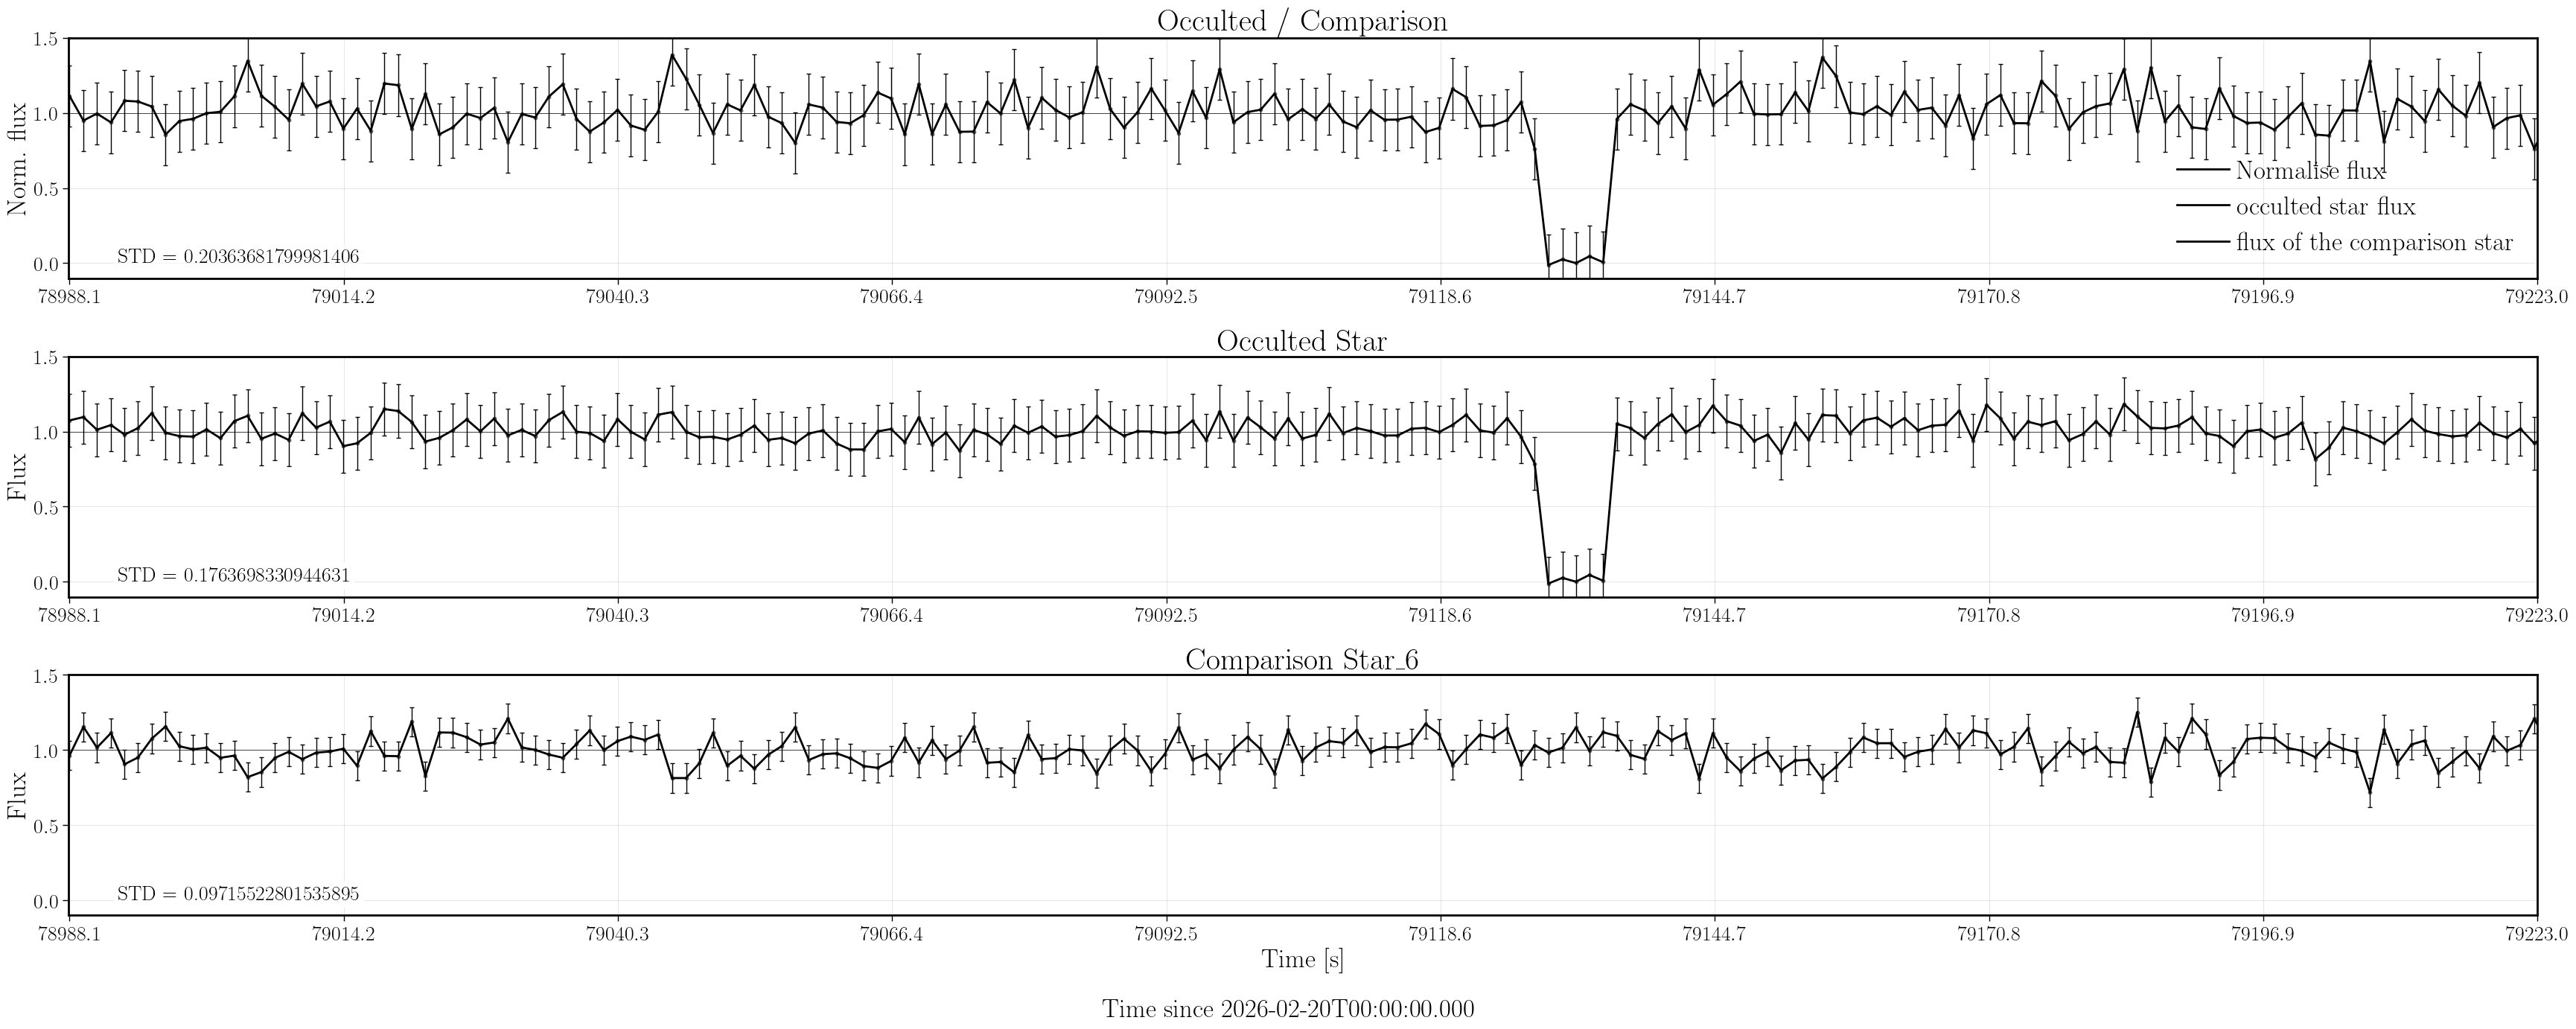

In [70]:
t0_midnight = Time(times[0].isot.split('T')[0] + 'T00:00:00',
                   format='isot', scale='utc')

target = np.concatenate([
    occulted_flux[0:105],
    occulted_flux[105:]
]).ravel()

std = np.std(target)

for idx, row in f_norm.iterrows():

    star = np.concatenate([
        row.values[0:105],
        row.values[105:]
    ]).ravel()

    star_std = np.std(star)

    occulted_flux = occulted_flux.ravel()
    comparison_star = row.values.ravel()

    star_normalise = occulted_flux / comparison_star  

    normalise = np.std(np.concatenate([
        star_normalise[0:105],
        star_normalise[105:]
    ]).ravel())

    fig, axes = plt.subplots(3, 1, figsize=(35, 14))
    axes = axes.flatten()

    # -----------------------------
    # 1. Normalised flux
    # -----------------------------
    axes[0].plot(time_sec, star_normalise,
                 linewidth=2, label='Normalise flux', color='black')

    axes[0].scatter(time_sec, star_normalise,
                    s=10, color='black', alpha=0.5)

    axes[0].errorbar(time_sec, star_normalise,
                     yerr=normalise,
                     fmt='none', ecolor='black',
                     elinewidth=1, capsize=2)

    axes[0].set_ylabel('Norm. flux', fontsize=25)
    axes[0].set_title('Occulted / Comparison', fontsize=30)
    axes[0].axhline(1, color='black', linewidth=0.5)
    axes[0].grid(alpha=0.3)

    axes[0].text(
        0.02, 0.05,
        f"STD = {normalise}",
        transform=axes[0].transAxes,
        fontsize=20,
        verticalalignment='bottom',
        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none')
    )

    # -----------------------------
    # 2. Occulted Star
    # -----------------------------
    axes[1].plot(time_sec, occulted_flux,
                 color='black', linewidth=2,
                 label='occulted star flux')

    axes[1].scatter(time_sec, occulted_flux,
                    s=10, color='black', alpha=0.5)

    axes[1].errorbar(time_sec, occulted_flux,
                     yerr=std,
                     fmt='none', ecolor='black',
                     elinewidth=1, capsize=2)

    axes[1].set_ylabel('Flux', fontsize=25)
    axes[1].set_title('Occulted Star', fontsize=30)
    axes[1].grid(alpha=0.3)
    axes[1].axhline(1, color='black', linewidth=0.5)

    axes[1].text(
        0.02, 0.05,
        f"STD = {std}",
        transform=axes[1].transAxes,
        fontsize=20,
        verticalalignment='bottom',
        bbox=dict(facecolor='white', alpha=1, edgecolor='none')
    )

    # -----------------------------
    # 3. Comparison Star
    # -----------------------------
    axes[2].plot(time_sec, comparison_star,
                 linewidth=2,
                 label='flux of the comparison star',
                 color='black')

    axes[2].scatter(time_sec, comparison_star,
                    s=10, color='black', alpha=0.5)

    axes[2].errorbar(time_sec, comparison_star,
                     yerr=star_std,
                     fmt='none', ecolor='black',
                     elinewidth=1, capsize=2)

    axes[2].set_xlabel('Time [s]', fontsize=25)
    axes[2].set_ylabel('Flux', fontsize=25)
    axes[2].set_title(f'Comparison Star_{idx}', fontsize=30)
    axes[2].grid(alpha=0.3)
    axes[2].axhline(1, color='black', linewidth=0.5)

    axes[2].text(
        0.02, 0.05,
        f"STD = {star_std}",
        transform=axes[2].transAxes,
        fontsize=20,
        verticalalignment='bottom',
        bbox=dict(facecolor='white', alpha=1, edgecolor='none')
    )

    # -----------------------------
    # Legend global
    # -----------------------------
    handles = []
    labels = []

    for ax in axes:
        h, l = ax.get_legend_handles_labels()
        handles += h
        labels += l

    axes[0].legend(handles, labels, loc = 'lower right', fontsize=25, frameon=False)

    # -----------------------------
    # Axes formatting
    # -----------------------------
    for ax in axes:
        ax.set_ylim(-0.1, 1.5)
        ax.set_xlim(78988, 79223)

    xticks = np.linspace(time_sec.min(), time_sec.max() - 1, 10)

    for ax in axes:
        ax.set_xticks(xticks)

    fig.text(0.5, 0.01,
             f"Time since {t0_midnight.isot}",
             ha='center', fontsize=25)

    plt.tight_layout(rect=[0, 0.03, 1, 1])
    plt.show()

The results that yield the best signal-to-noise ratio when normalizing via differential photometry correspond to the star labeled as **Curve 0**. This curve is represented below in greater detail, focusing on the area near the occultation to show the symmetry of the smaller peaks surrounding it. These flux drops would indicate the existence of rings.

/tmp/ipykernel_1221/1891374660.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0, 0.5, 'normalize flux')

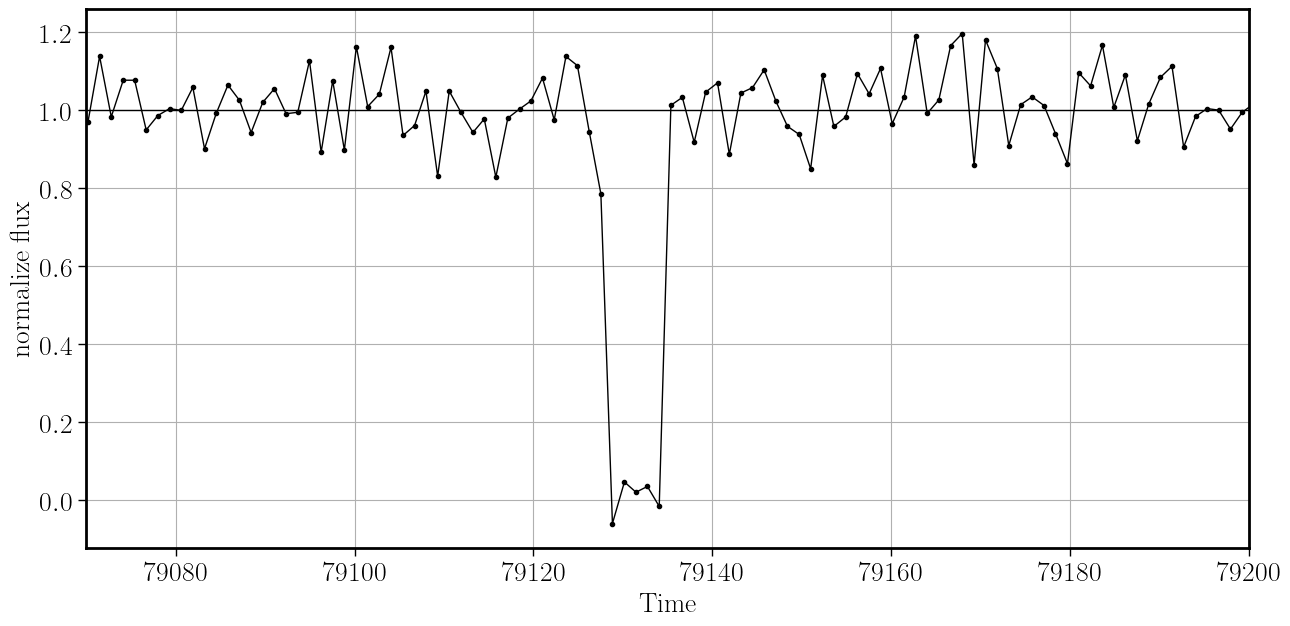

In [130]:
comparison_star = f_norm.loc[0].values.ravel()

normalized_occulted = occulted_flux.ravel() / comparison_star
plt.figure(figsize=(15, 7))

#plt.scatter(time_sec, normalized_occulted,
#        edgecolors='black', color = 'black',
#        alpha=0.7, label = f'occulted star')

plt.plot(time_sec, normalized_occulted,
        color='black',
        marker='.',
        linewidth=1)
plt.axhline(1, color = 'black', linewidth = 1)

plt.xlabel('Time')
plt.xlim(79070,79200)
plt.grid()
plt.legend()
plt.ylabel('normalize flux')

Once we have the curves, we must fit the most suitable model to extract the relevant information. To do this, we will use the [SORA](https://sora.readthedocs.io/latest/modules/lightcurve.html#) library. In particular, to obtain the occultation data, we will work with the `sora.lightcurve` module, though it will not be the only one used.

To plot and fit the light curve, we also need information about the object, such as its distance and velocity, as well as specific data regarding the star. Therefore, we will also utilize the `sora.prediction` and `sora.Body` modules.

In [124]:
from sora import LightCurve
from sora.prediction import prediction 
from sora.body import Body 

lc = LightCurve(
    name="Biennor",
    time=time_sec,
    flux=normalized_occulted,
    exptime= 1.0 ,
    tref=143
)

params = lc.occ_detect()
params

Biennor = Body(name = 'Bienor', ephem = ['/mnt/c/Users/Francisco/Desktop/IAA/Bsp_files/Bienor.bsp', '/mnt/c/Users/Francisco/Desktop/IAA/Bsp_files/de438.bsp'])

pred = prediction(body = Biennor, time_beg='2026-02-20', time_end='2026-02-21', mag_lim=17)

lc.dist = pred['Dist'][0]      
lc.vel = pred['Vel'][0] 
lc.d_star = 0.02
model = lc.occ_lcfit()

/home/franeko/IAA/haumea-osn-2017/venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 1 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/franeko/IAA/haumea-osn-2017/venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 182 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/franeko/IAA/haumea-osn-2017/venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 181 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/franeko/IAA/haumea-osn-2017/venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 181 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/franeko/IAA/haumea-osn-2017/venv/lib/python3.12/site-packages/erfa/core.py:133: Erfa

Obtaining data for Bienor from SBDB
Ephemeris was split in 1 parts for better search of stars

Searching occultations in part 1/1
Generating Ephemeris between 2026-02-20 00:00:00.000 and 2026-02-20 23:59:00.000 ...
    2 GaiaDR3 stars downloaded
Identifying occultations ...

1 occultations found.
LightCurve fit: |████████████████████████████████████████|  - 100% 


/home/franeko/IAA/haumea-osn-2017/venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 1 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/franeko/IAA/haumea-osn-2017/venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 1 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/franeko/IAA/haumea-osn-2017/venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 1 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/franeko/IAA/haumea-osn-2017/venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 1 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


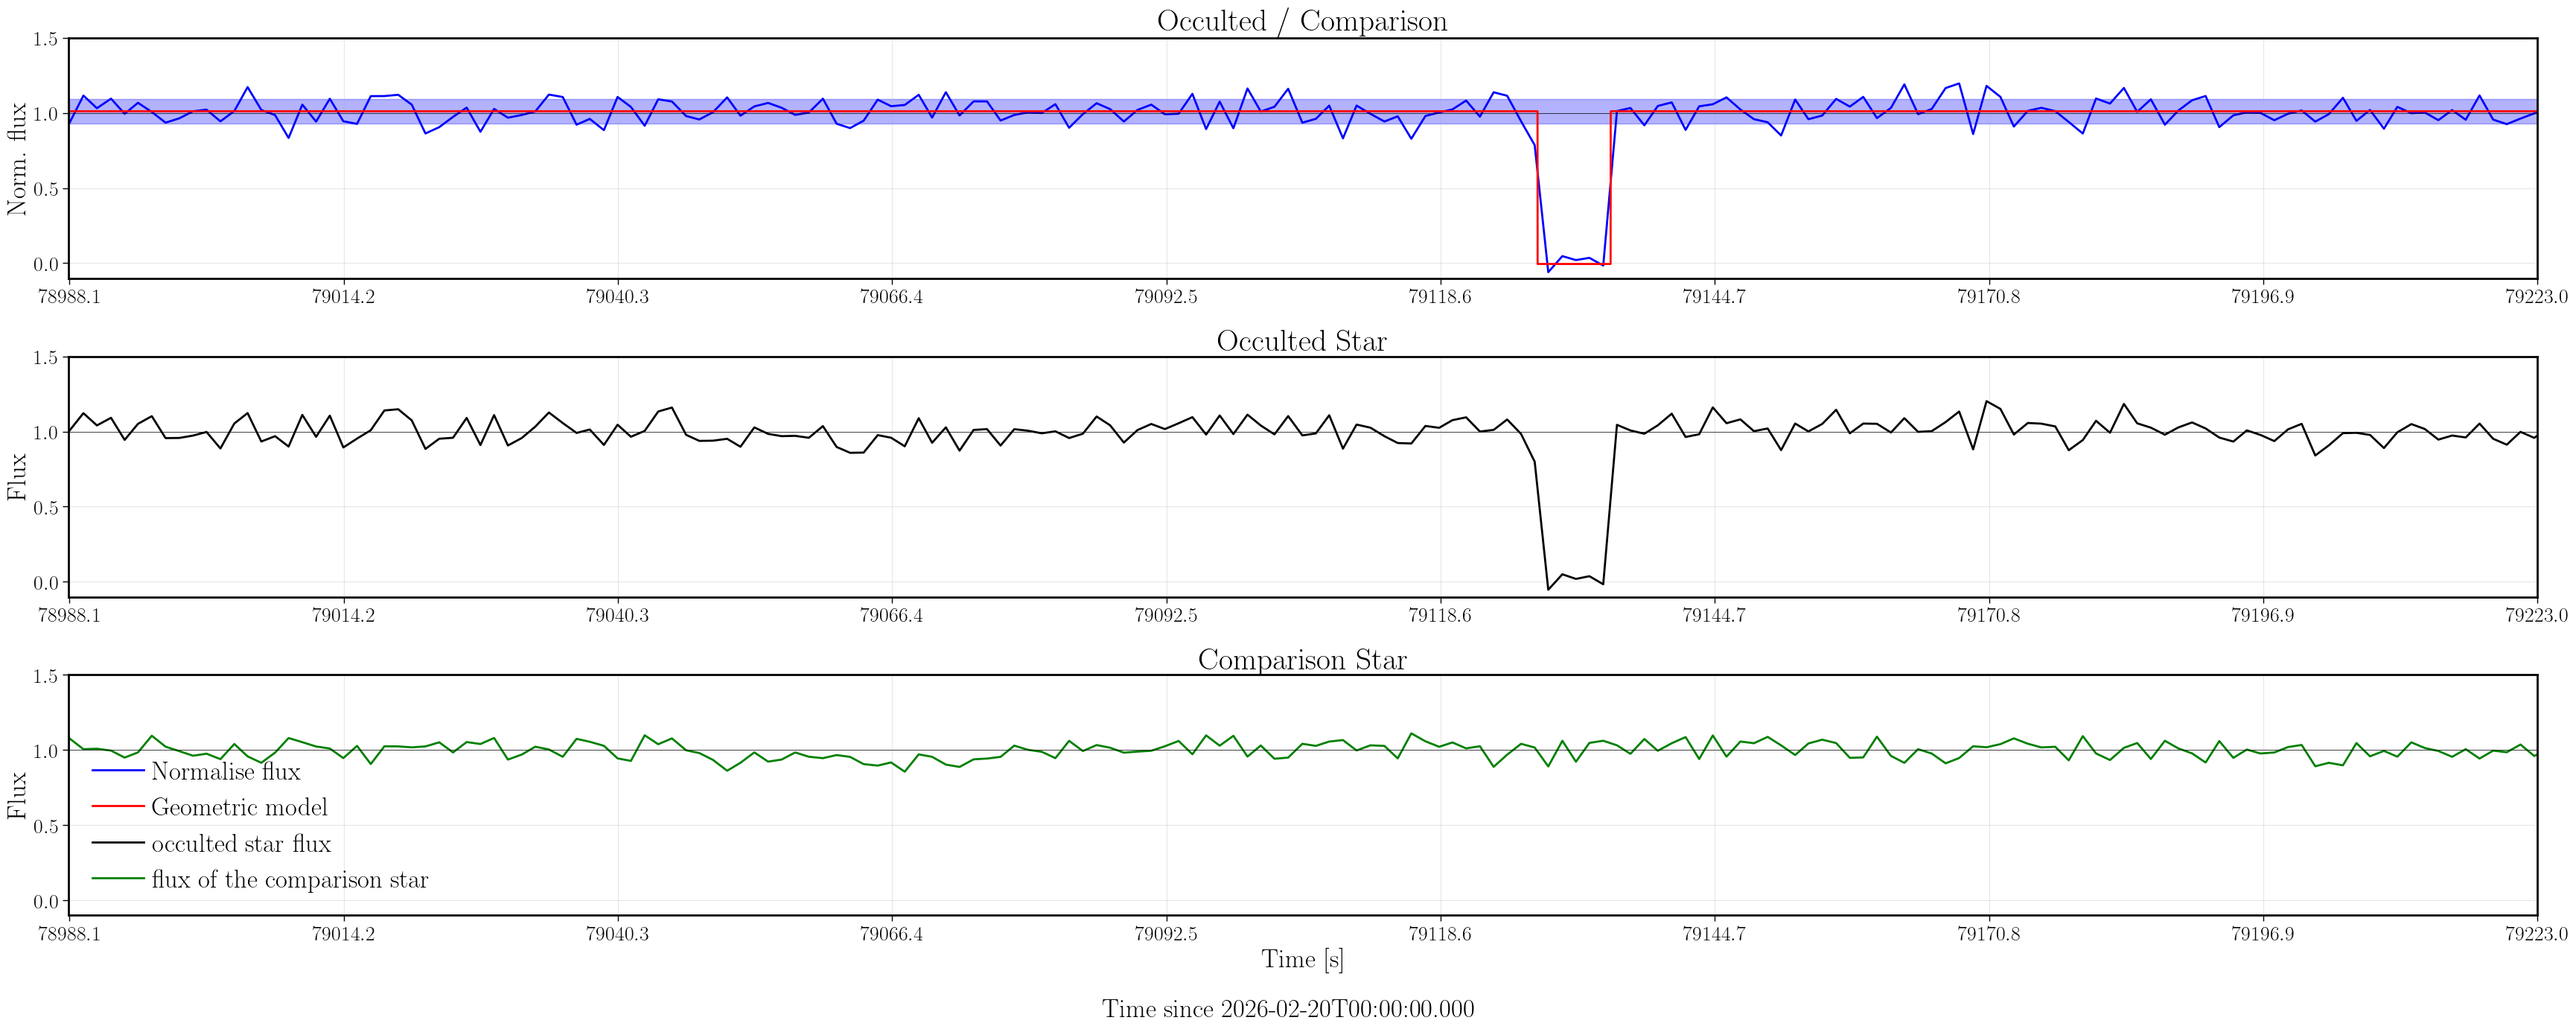

In [157]:
t0_midnight = Time(times[0].isot.split('T')[0] + 'T00:00:00',
                format='isot', scale='utc')

fig, axes = plt.subplots(3, 1, figsize=(35, 14))
axes = axes.flatten()

axes[0].plot(time_sec, normalized_occulted, linewidth=2, label = 'Normalise flux', color = 'blue')
axes[0].set_ylabel('Norm. flux', fontsize=25)
axes[0].set_title('Occulted / Comparison', fontsize=30)
axes[0].axhline(1, color='black', linewidth=0.5)
axes[0].grid(alpha=0.3)
axes[0].plot(lc.time_model, lc.model_geometric,
             color='red', linewidth=2, label='Geometric model')
axes[0].fill_between(time_sec, params['baseline'] - params['baseline_err'], params['baseline'] + params['baseline_err'], alpha=0.3, color='blue')

axes[1].plot(time_sec, occulted_flux.ravel(),
                color='black', linewidth=2, label = 'occulted star flux',)
axes[1].set_ylabel('Flux', fontsize=25)
axes[1].set_title('Occulted Star', fontsize=30)
axes[1].grid(alpha=0.3)
axes[1].axhline(1, color='black', linewidth=0.5)
#axes[1].fill_between(time_sec, occulted_flux - std, occulted_flux + std, alpha=0.3, color='black')

axes[2].plot(time_sec, comparison_star,
                linewidth=2, label = 'flux of the comparison star', color = 'green')
axes[2].set_xlabel('Time [s]', fontsize=25)
axes[2].set_ylabel('Flux', fontsize=25)
axes[2].set_title(f'Comparison Star', fontsize=30)
axes[2].grid(alpha=0.3)
axes[2].axhline(1, color='black', linewidth=0.5)
#axes[2].fill_between(time_sec, comparison_star - star, comparison_star + star, alpha=0.3, color='green')

handles = []
labels = []

for ax in axes:
    h, l = ax.get_legend_handles_labels()
    handles += h
    labels += l

axes[2].legend(handles, labels, loc='lower left', fontsize=25, frameon=False)

for ax in axes:
    ax.set_ylim(-0.1, 1.5)
    ax.set_xlim(78988,79223)

xticks = np.linspace(time_sec.min(), time_sec.max() -1, 10)

for ax in axes:
    ax.set_xticks(xticks)

fig.text(0.5, 0.01,
            f"Time since {t0_midnight.isot}",
            ha='center', fontsize=25)

plt.tight_layout(rect=[0, 0.03, 1, 1]) 
plt.show()

# Apendix 1

In this appendix, we aim to examine the changes observed in the normalized flux of the selected stars when modifying the parameters used to obtain that normalized flux. Specifically, these parameters include the annuli used to estimate the background and the aperture used to measure the star’s flux.

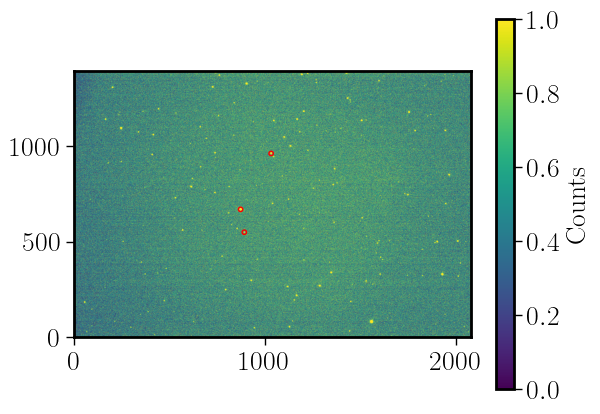

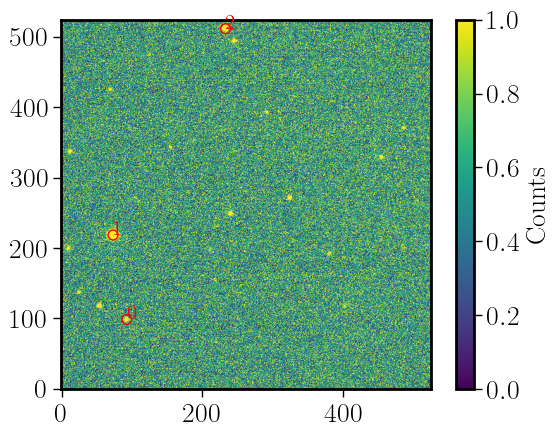

In [ ]:
with fits.open(os.path.join(root,'Biennor_00001.fits')) as hdul:
    data = hdul[0].data

reduction = data[450:975,800:1325]

mean, median, std = sigma_clipped_stats(reduction, sigma=20.0)  #
daofind = DAOStarFinder(fwhm=3.0, threshold=10.*std)
sources = daofind(reduction - median)

plt.imshow(data, origin = 'lower', vmin = np.median(data) - np.std(data), vmax = np.median(data) + np.std(data))
if sources is not None and len(sources) > 0:
    plt.scatter(sources['xcentroid'] + 800, sources['ycentroid'] +  450, 
                s=10, facecolors='none', edgecolors='red', label='Detected sources')
plt.colorbar(label ='Counts')
plt.show()

mean, median, std = sigma_clipped_stats(reduction, sigma=20.0)  #
daofind = DAOStarFinder(fwhm=3.0, threshold=10.*std)
sources = daofind(reduction - median)

plt.imshow(reduction, origin = 'lower', vmin = np.median(data) - np.std(data), vmax = np.median(data) + np.std(data))
if sources is not None and len(sources) > 0:
    plt.scatter(sources['xcentroid'] , sources['ycentroid'] ,
                s=50, facecolors='none', edgecolors='red', label='Detected sources')
for i, (x, y) in enumerate(zip(sources['xcentroid'], sources['ycentroid'])):
        plt.text(x, y, str(i), color='red', fontsize=15)

plt.colorbar(label ='Counts')
plt.show()

In [7]:
sources

id,xcentroid,ycentroid,sharpness,roundness1,roundness2,npix,peak,flux,mag,daofind_mag
int64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64
1,92.49094549869159,98.60691901297679,0.7645820485418775,0.06921624783942126,0.053198820504739903,25,466.0,4536.0,-9.141682614712126,-0.05526994154911864
2,72.9967389345795,218.5141320971344,0.44080887080709985,0.2728034734302766,0.15817829601283068,25,11990.0,144077.0,-12.89648664234848,-3.8158489040985923
3,233.0000326551832,511.5768563865627,0.38022225098271056,0.22517054637392298,-0.05632242537473419,25,1134.0,14453.0,-10.399895006696298,-1.2975160773619832


We will focus on a star that has a flux similar to the ones we used to compare the normalized flux of the occulted star. Therefore, we selected the first star, which has a flux close to 4500.

In [8]:
df = sources[sources['id'] == 1]
df

id,xcentroid,ycentroid,sharpness,roundness1,roundness2,npix,peak,flux,mag,daofind_mag
int64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64
1,92.49094549869159,98.60691901297679,0.7645820485418775,0.06921624783942126,0.053198820504739903,25,466.0,4536.0,-9.141682614712126,-0.05526994154911864


In [16]:
positions = np.transpose((df['xcentroid'], df['ycentroid']))

radii = [7, 8, 9, 10, 11]

results = {}

for radius in radii:

    apertures = CircularAperture(positions, r=radius)
    annuli = CircularAnnulus(positions, r_in=radius, r_out=radius + 5)

    flux_matrix = []

    for observation in images_2:

        # --- flujo en apertura ---
        ap_stats = ApertureStats(observation, apertures)
        flux_ap = ap_stats.sum

        # --- background ---
        bkg_stats = ApertureStats(observation, annuli)
        bkg_median = bkg_stats.median

        # --- área de la apertura ---
        area = apertures.area

        # --- flujo corregido ---
        flux_corr = flux_ap - bkg_median * area

        flux_matrix.append(flux_corr)

    # convertir a array (estrellas x imágenes)
    flux_matrix = np.array(flux_matrix).T
    results[f"r_{radius}"] = flux_matrix


In [19]:
data = []

for key, matrix in results.items():
    flux = matrix.flatten()  # o matrix[0]
    data.append(flux)

# (radios × imágenes)
data = np.array(data)

df_radii = pd.DataFrame(
    data,
    index=list(results.keys()),
    columns=[f'image_{i}' for i in range(data.shape[1])]
)

f_norm = df_radii.div(df_radii.median(axis=1), axis=0)

In [20]:
f_norm

,image_0,image_1,image_2,image_3,image_4,image_5,image_6,image_7,image_8,image_9,image_10,image_11,image_12,image_13,image_14,image_15,image_16,image_17,image_18,image_19,image_20,image_21,image_22,image_23,image_24,image_25,image_26,image_27,image_28,image_29,image_30,image_31,image_32,image_33,image_34,image_35,image_36,image_37,image_38,image_39,image_40,image_41,image_42,image_43,image_44,image_45,image_46,image_47,image_48,image_49,image_50,image_51,image_52,image_53,image_54,image_55,image_56,image_57,image_58,image_59,image_60,image_61,image_62,image_63,image_64,image_65,image_66,image_67,image_68,image_69,image_70,image_71,image_72,image_73,image_74,image_75,image_76,image_77,image_78,image_79,image_80,image_81,image_82,image_83,image_84,image_85,image_86,image_87,image_88,image_89,image_90,image_91,image_92,image_93,image_94,image_95,image_96,image_97,image_98,image_99,image_100,image_101,image_102,image_103,image_104,image_105,image_106,image_107,image_108,image_109,image_110,image_111,image_112,image_113,image_114,image_115,image_116,image_117,image_118,image_119,image_120,image_121,image_122,image_123,image_124,image_125,image_126,image_127,image_128,image_129,image_130,image_131,image_132,image_133,image_134,image_135,image_136,image_137,image_138,image_139,image_140,image_141,image_142,image_143,image_144,image_145,image_146,image_147,image_148,image_149,image_150,image_151,image_152,image_153,image_154,image_155,image_156,image_157,image_158,image_159,image_160,image_161,image_162,image_163,image_164,image_165,image_166,image_167,image_168,image_169,image_170,image_171,image_172,image_173,image_174,image_175,image_176,image_177,image_178,image_179,image_180,image_181
r_7,0.972602,0.973096,1.026357,0.981793,1.005355,1.040966,0.987800,1.111450,0.996575,0.929988,1.001908,0.976929,1.101169,0.968203,1.002797,0.958333,1.046561,1.020851,1.014334,0.997736,0.969134,1.021887,0.961386,1.038427,1.035907,0.957699,1.015227,1.028886,1.091059,1.021434,1.086871,1.079100,0.958465,0.996541,1.018510,0.956942,0.929779,0.979937,0.987143,1.148905,0.982037,0.853832,1.051088,1.027228,1.042713,0.993357,1.030601,0.890488,0.797912,1.018853,1.029551,1.011593,0.933199,1.047302,0.971081,1.037278,0.932433,1.083205,0.873564,0.893507,0.991507,0.917282,1.079593,1.052692,0.875595,0.913188,1.046775,0.981368,0.972660,0.971966,1.035468,0.912673,1.011372,1.179931,1.017318,1.095261,0.967926,1.036330,1.017861,0.980318,1.164437,0.937090,0.972797,1.052810,1.055224,1.032630,0.967568,1.030402,1.004469,0.920914,0.965533,0.985944,1.002142,1.109588,0.945619,1.006223,1.068338,0.935461,1.040479,1.038888,0.971560,0.982699,1.060542,1.007440,0.871945,0.945215,1.110278,0.951986,0.841876,1.036870,0.921659,1.063092,0.978409,1.034462,0.991317,1.031408,0.931633,1.043515,1.092586,0.875720,1.100964,0.953947,0.998556,1.051365,1.031190,1.094062,0.969340,0.942418,1.065030,1.011294,0.964717,0.911244,1.036803,0.995912,0.975811,1.010744,0.926839,0.991560,0.943827,0.991300,1.041120,0.922871,1.039240,1.080878,0.960090,0.944976,1.025910,1.017309,0.970736,0.961444,0.956498,1.007609,0.969354,0.982568,1.008602,1.031116,0.905673,1.045862,0.937817,0.952152,0.989588,0.983151,1.038619,1.047995,0.896892,0.973709,0.961705,1.046616,0.883163,0.975200,1.024590,1.186456,1.065991,0.975950,1.001444,1.032164,1.006045,1.014160,1.023849,1.075388,0.917660,0.976421
r_8,0.943603,0.971715,1.020421,0.987733,0.947803,1.034552,0.952012,1.113733,1.035818,0.946034,0.993138,1.011760,1.086899,1.012721,0.990041,1.007837,1.024810,1.076061,0.878947,1.018709,0.981913,0.982641,0.983871,1.012690,1.095405,0.957316,1.068893,1.047237,1.075518,0.974716,1.082651,1.063490,0.972701,0.976981,1.072496,0.912037,0.898847,0.921221,0.972687,1.086865,0.951512,0.860412,1.006004,0.994087,1.058318,1.011316,1.111000,0.983343,0.788830,1.078140,1.076131,1.053457,0.949139,1.059618,0.936633,1.062884,0.944564,1.057271,0.878986,0.860382,0.975895,0.947849,1.111327,1.121732,0.810346,0.971767,1.059310,0.991402,0.990707,0.924953,1.051551,0.88

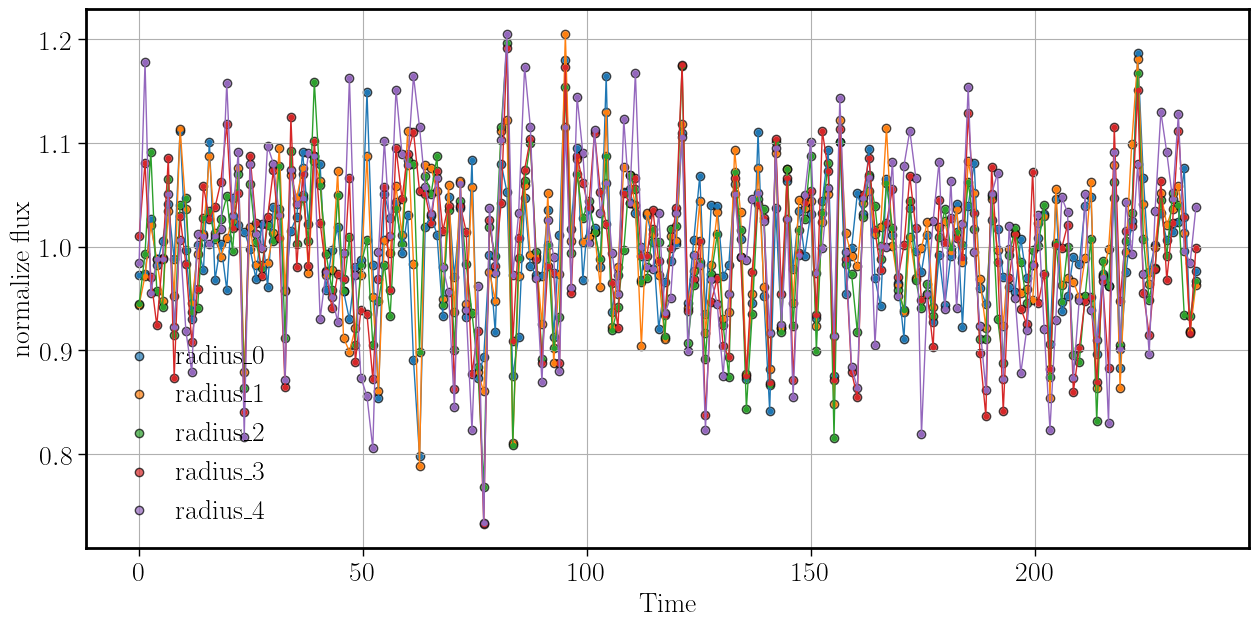

In [25]:
for dirpath, dirnames, filenames in os.walk(root):
    filenames = sorted(filenames)
    filenames = filenames[1:]

times = []

for f in filenames:
    with fits.open(os.path.join(root,f)) as hdul:
        header = hdul[0].header
        
        # usa el timestamp real del frame
        t = Time(header['DATE-AVG'], format='isot', scale='utc')
        times.append(t)

times = Time(times)

times

time_sec = (times - times[0]).sec

colors = [
    "tab:blue",
    "tab:orange",
    "tab:green",
    "tab:red",
    "tab:purple",
]

plt.figure(figsize=(15, 7))

for i, (idx, row) in enumerate(f_norm.iterrows()):

    plt.scatter(time_sec, row.values,
            edgecolors='black', color = colors[i],
            alpha=0.7, label = f'radius_{i}')

    plt.plot(time_sec, row.values,
            marker='.',
            linewidth=1)
        
    #plt.xlim(100,200)
    plt.xlabel('Time')
    plt.grid()
    plt.legend()
    plt.ylabel('normalize flux')

In [49]:
for idx, row in f_norm.iterrows():
    print(f'{np.median(row)} +- {np.std(row)}')
    print(f'{np.mean(row)} +- {np.std(row)}')


1.0 +- 0.06191737206238336
0.9986934850189896 +- 0.06191737206238336
1.0 +- 0.06822432616923134
0.9996009483907969 +- 0.06822432616923134
1.0 +- 0.07112401024708566
0.9929200308412632 +- 0.07112401024708566
1.0 +- 0.07760705002149917
0.9955100846138919 +- 0.07760705002149917
1.0 +- 0.08741816741883557
1.0013182969656031 +- 0.08741816741883557


It is true that the median and mean of the normalized flux values behave as expected; however, we observe greater fluctuations as the radius of the aperture used to extract the stellar flux increases. This is somewhat counterintuitive, since even when using a larger radius (which eventually includes mostly background noise), we estimate and subtract the background around the star for each pixel inside the aperture, so the resulting values should not differ significantly.

Nevertheless, this does not seem to be the case. In fact, between a radius of r = 7 and r = 11, we observe a difference of about two hundredths in the standard deviation of the already normalized measurements, which can be a significant variation.

For this reason, in this work we adopt a radius of r = 7, as it provides the lowest level of fluctuations for the reference star typically used in the observation of the occulted star.

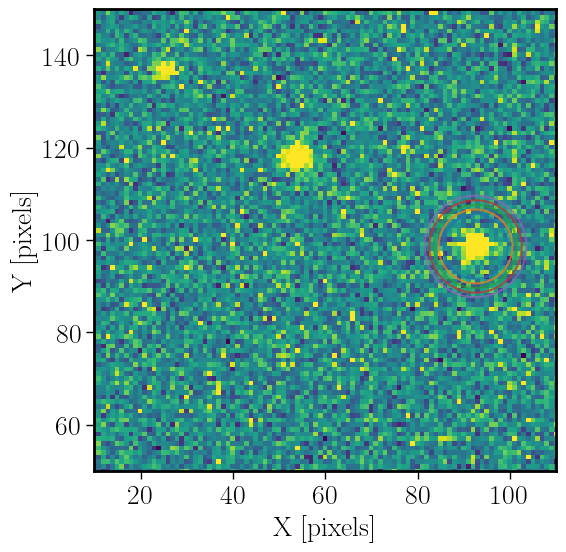

In [48]:
if sources is not None and len(sources) > 0:
    positions = np.transpose((sources['xcentroid'], sources['ycentroid']))
else:
    positions = []

colors = [
    "tab:blue",
    "tab:orange",
    "tab:green",
    "tab:red",
    "tab:purple",
]

radii = [7, 8, 9, 10, 11]
plt.figure(figsize=(8,6))

for i, radius in enumerate(radii):

    apertures = CircularAperture(positions, r=radius)
    plt.imshow(reduction, origin='lower', 
            vmin=np.median(reduction)-np.std(reduction), 
            vmax=np.median(reduction)+np.std(reduction))

    if apertures is not None:
        apertures.plot(color=colors[i], lw=1.5, alpha=0.7)

    plt.xlim(10,110)
    plt.ylim(50,150)
    plt.xlabel('X [pixels]')
    plt.ylabel('Y [pixels]')

# Appendix 2

In this appendix we examinate how to convert the Right Ascension (RA) and Declination (Dec) into pixels in order to obtain the pixels of the occulted star. For our object (the star) have the following coordinates:

- **Right Ascension (RA):** 07h 59m 00.000s  
- **Declination (Dec):** +35° 42′ 44.000″  


To identify the star in the images, we convert coordinates (RA, Dec) into pixels using the WCS transformation:

$$
\begin{pmatrix}
\alpha \\
\delta
\end{pmatrix}
=
\begin{pmatrix}
\mathrm{CD1\_1} & \mathrm{CD1\_2} \\
\mathrm{CD2\_1} & \mathrm{CD2\_2}
\end{pmatrix}
\begin{pmatrix}
X - \mathrm{CRPIX1} \\
Y - \mathrm{CRPIX2}
\end{pmatrix}
+
\begin{pmatrix}
\mathrm{CRVAL1} \\
\mathrm{CRVAL2}
\end{pmatrix}
$$

The idea behind this appendix was based on the assumption that, in order to work with this type of photometric images, the first step should be to convert the entire image into right ascension and declination coordinates. However, as shown in the code below, applying this transformation using the given formula introduces a distortion in the photometric image. This distortion prevents us from continuing to work with it, since we are effectively trying to map an image of the celestial sphere, with its spherical geometry, onto a 2D plane. Therefore, this approach is not useful.

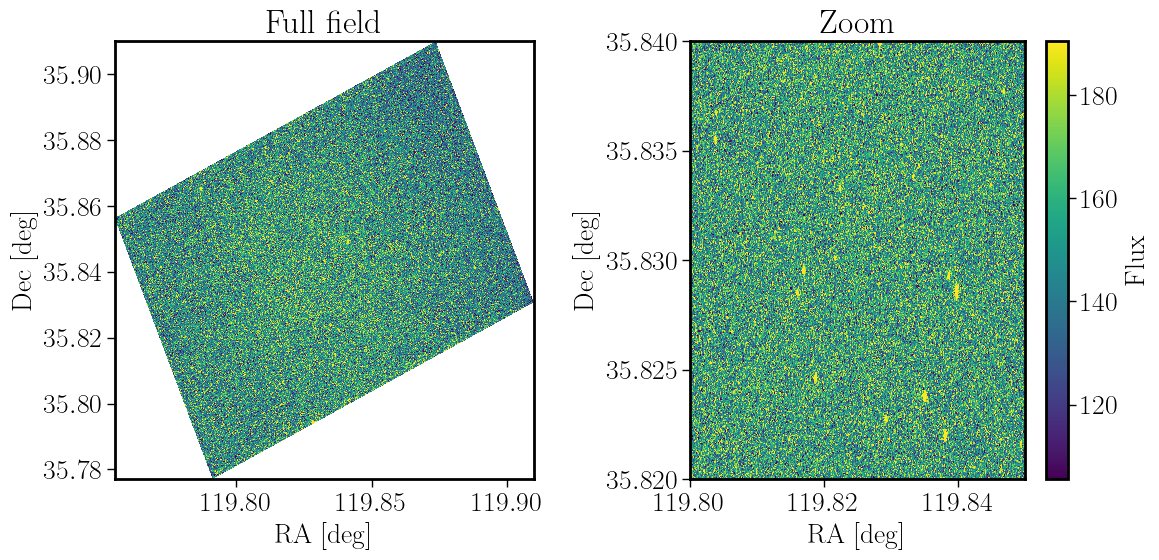

In [32]:
with fits.open(os.path.join(root,'Biennor_00001.fits')) as hdul:
    CD1_1, CD1_2  = hdul[0].header['CD1_1'], hdul[0].header['CD1_2']
    CD2_1, CD2_2  = hdul[0].header['CD2_1'], hdul[0].header['CD2_2']
    CRPIX1, CRPIX2 = hdul[0].header['CRPIX1'], hdul[0].header['CRPIX2']
    CRVAL1, CRVAL2 = hdul[0].header['CRVAL1'], hdul[0].header['CRVAL2']

    data = hdul[0].data
    ny, nx = data.shape

    
X = np.arange(nx)
Y = np.arange(ny)

X_grid, Y_grid = np.meshgrid(X, Y)

# Transformación a RA/Dec
RA = CD1_1 * (X_grid - CRPIX1) + CD1_2 * (Y_grid - CRPIX2) + CRVAL1
Dec = CD2_1 * (X_grid - CRPIX1) + CD2_2 * (Y_grid - CRPIX2) + CRVAL2

fig, axs = plt.subplots(1, 2, figsize=(12,6))

vmin = np.median(data) - np.std(data)
vmax = np.median(data) + np.std(data)

# --- Izquierda (imagen completa)
im1 = axs[0].pcolormesh(RA, Dec, data, vmin=vmin, vmax=vmax)
axs[0].set_xlabel("RA [deg]")
axs[0].set_ylabel("Dec [deg]")
axs[0].set_title("Full field")

# --- Derecha (zoom)
im2 = axs[1].pcolormesh(RA, Dec, data, vmin=vmin, vmax=vmax)
axs[1].set_xlabel("RA [deg]")
axs[1].set_ylabel("Dec [deg]")
axs[1].set_xlim(119.80, 119.85)
axs[1].set_ylim(35.82, 35.84)
axs[1].set_title("Zoom")

# Colorbar común
fig.colorbar(im1, ax=axs[1], label='Flux')

plt.tight_layout()
plt.show()

Since we cannot work with the image in right ascension and declination, another approach to identify the occulted star—if it is not located at the center—would be to convert the coordinates of the observed object from right ascension and declination into pixel coordinates, working with the same image grid. To do this, we can work with the World Coordinate System ([astropy.wcs](https://docs.astropy.org/en/latest/wcs/index.html)).

World Coordinate System describe the geometric transformations between one set of coordinate and another. A common application is to map the pixels in an image onto the celestial sphere. Another common application is to map pixels to wavelength in a spectrum (How we use [here](https://github.com/FranRuizLopez/Integral-Field-Spectroscopy-IFU-)).

How I said before, in the following example I am going to estimate the pixels coordinates of the star occulted. According to the document header, the celestial coordinates of the star are: 

OBJCTDEC= '+35 42 44.000'      / Epoch : JNOW                                   
OBJCTRA = '07 59 00.000'       / Epoch : JNOW



In [41]:
with fits.open(os.path.join(root,'Biennor_00001.fits')) as hdul:
    head = hdul[0].header

sky = SkyCoord("07h59m00.000s +35d42m44.000s", frame='icrs')

w = WCS(head)
x, y = w.world_to_pixel(sky)

print(x, y)

3111.173080348638 2062.6338986662936


Set MJD-AVG to 61091.914214 from DATE-AVG.
Set MJD-END to 61091.914220 from DATE-END'. [astropy.wcs.wcs]


Obviously, the values are incorrect since the coordinates provided are larger than the actual dimensions we observe in the FITS header. Therefore, it is possible that the coordinates given in the header or in the note are incorrect. This can be seen much more clearly in the following image, where the red point represents the estimated coordinates of the location of the object we are working with.

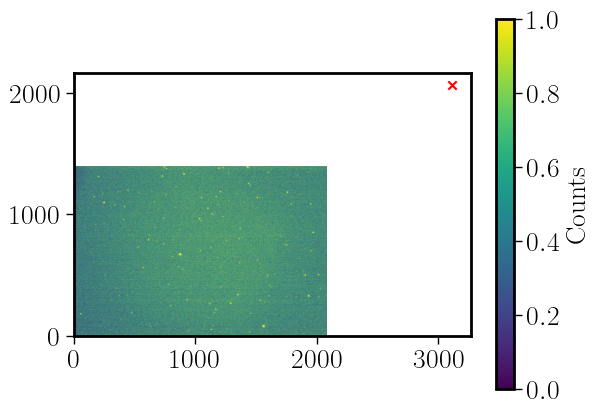

In [44]:
plt.imshow(data, origin = 'lower', vmin = np.median(data) - np.std(data), vmax = np.median(data) + np.std(data))
plt.scatter(x, y, color ='red', marker = 'x', alpha = 1)
plt.colorbar(label = 'Counts')
plt.show()

I am checking the Occultation Portal and it seems that the star that will be occulted on 20/02/26 has celestial coordinates different from those listed in the FITS file. The coordinates are:

RA = 07 57 16.4841  
DEC = +35 46 55.826

However, using these coordinates, the pixel positions still do not fall within the image, and certainly not on the occulted star.

In [45]:
with fits.open(os.path.join(root,'Biennor_00001.fits')) as hdul:
    head = hdul[0].header

sky = SkyCoord("07h57m16.4841s +35d46m55.826s", frame='icrs')

w = WCS(head)
x, y = w.world_to_pixel(sky)

Set MJD-AVG to 61091.914214 from DATE-AVG.
Set MJD-END to 61091.914220 from DATE-END'. [astropy.wcs.wcs]


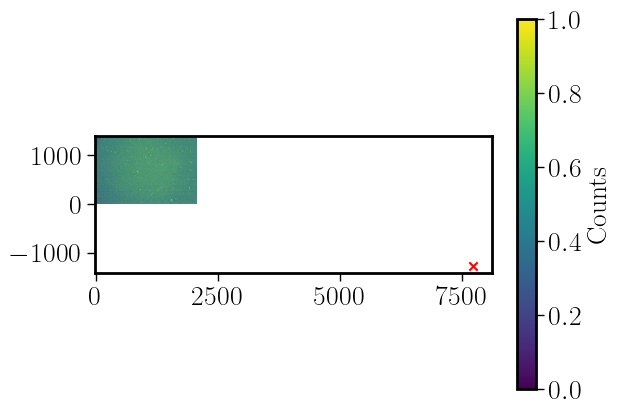

In [51]:
plt.imshow(data, origin = 'lower', vmin = np.median(data) - np.std(data), vmax = np.median(data) + np.std(data))
plt.scatter(x, y, color ='red', marker = 'x', alpha = 1)
plt.colorbar(label = 'Counts')
plt.show()

I will try to do it the other way around, i.e. take the pixel coordinates where the star is located and convert them into celestial coordinates, in order to see whether they differ significantly from those provided either by the FITS file or by the Occultation Portal.

In [57]:
with fits.open(os.path.join(root,'Biennor_00001.fits')) as hdul:
    head = hdul[0].header

w = WCS(head)
sky = w.pixel_to_world(1041, 698)
#print(sky)

ra_deg = sky.ra
dec_deg = sky.dec

print('RA:')
print(ra_deg.to_string(unit=u.hourangle, sep=':'))
print('Dec:')
print(dec_deg.to_string(sep=':'))

RA:
7:59:24.40826431
Dec:
35:50:35.60030358


Set MJD-AVG to 61091.914214 from DATE-AVG.
Set MJD-END to 61091.914220 from DATE-END'. [astropy.wcs.wcs]


# Appendix 3

This appendix aims to understand the use of the first and second derivatives as a method to obtain the light curve of the star that most closely resembles the light curve of the occulted star (except, precisely, during the occultation).

When working with light curves, what we have is the flux function sampled at equally spaced time intervals, i.e., it is not a continuous function. For these cases, the definition of the derivative can be approximated by the following expression:

$$
\frac{dx}{dt} \approx \frac{x_{i+1} - x_i}{t_{i+1} - t_i}
$$

This derivative measures the change per unit time, or in other words, the slope of the function being analyzed. Therefore, when applying a curve comparison method, we obtain two derivative curves that can be compared, being similar if both increase or decrease simultaneously, allowing us to identify similar behavior in both curves.

For the second derivative, given by the following expression:

$$
\frac{d^2x}{dt^2} \approx \frac{x_{i+1} - 2x_i + x_{i-1}}{(t_{i+1} - t_i)^2}
$$

we obtain how the slope of the analyzed vector changes, essentially describing the curvature of the function. Comparing these curves also allows us to identify which ones share similar structural behavior.

In the context of curve comparison, the first derivative allows us to identify similarity in the direction of change, while the second derivative allows us to identify similarity in the shape of the transition, being more sensitive to fine structures such as edges or abrupt changes.

Next, in order to better understand how the derivative of the vector acts on our light curves, we will plot the derivatives of each of the curves, and later the second derivative of the curves. To do this, we will use the `gradient` function from the `numpy` library.

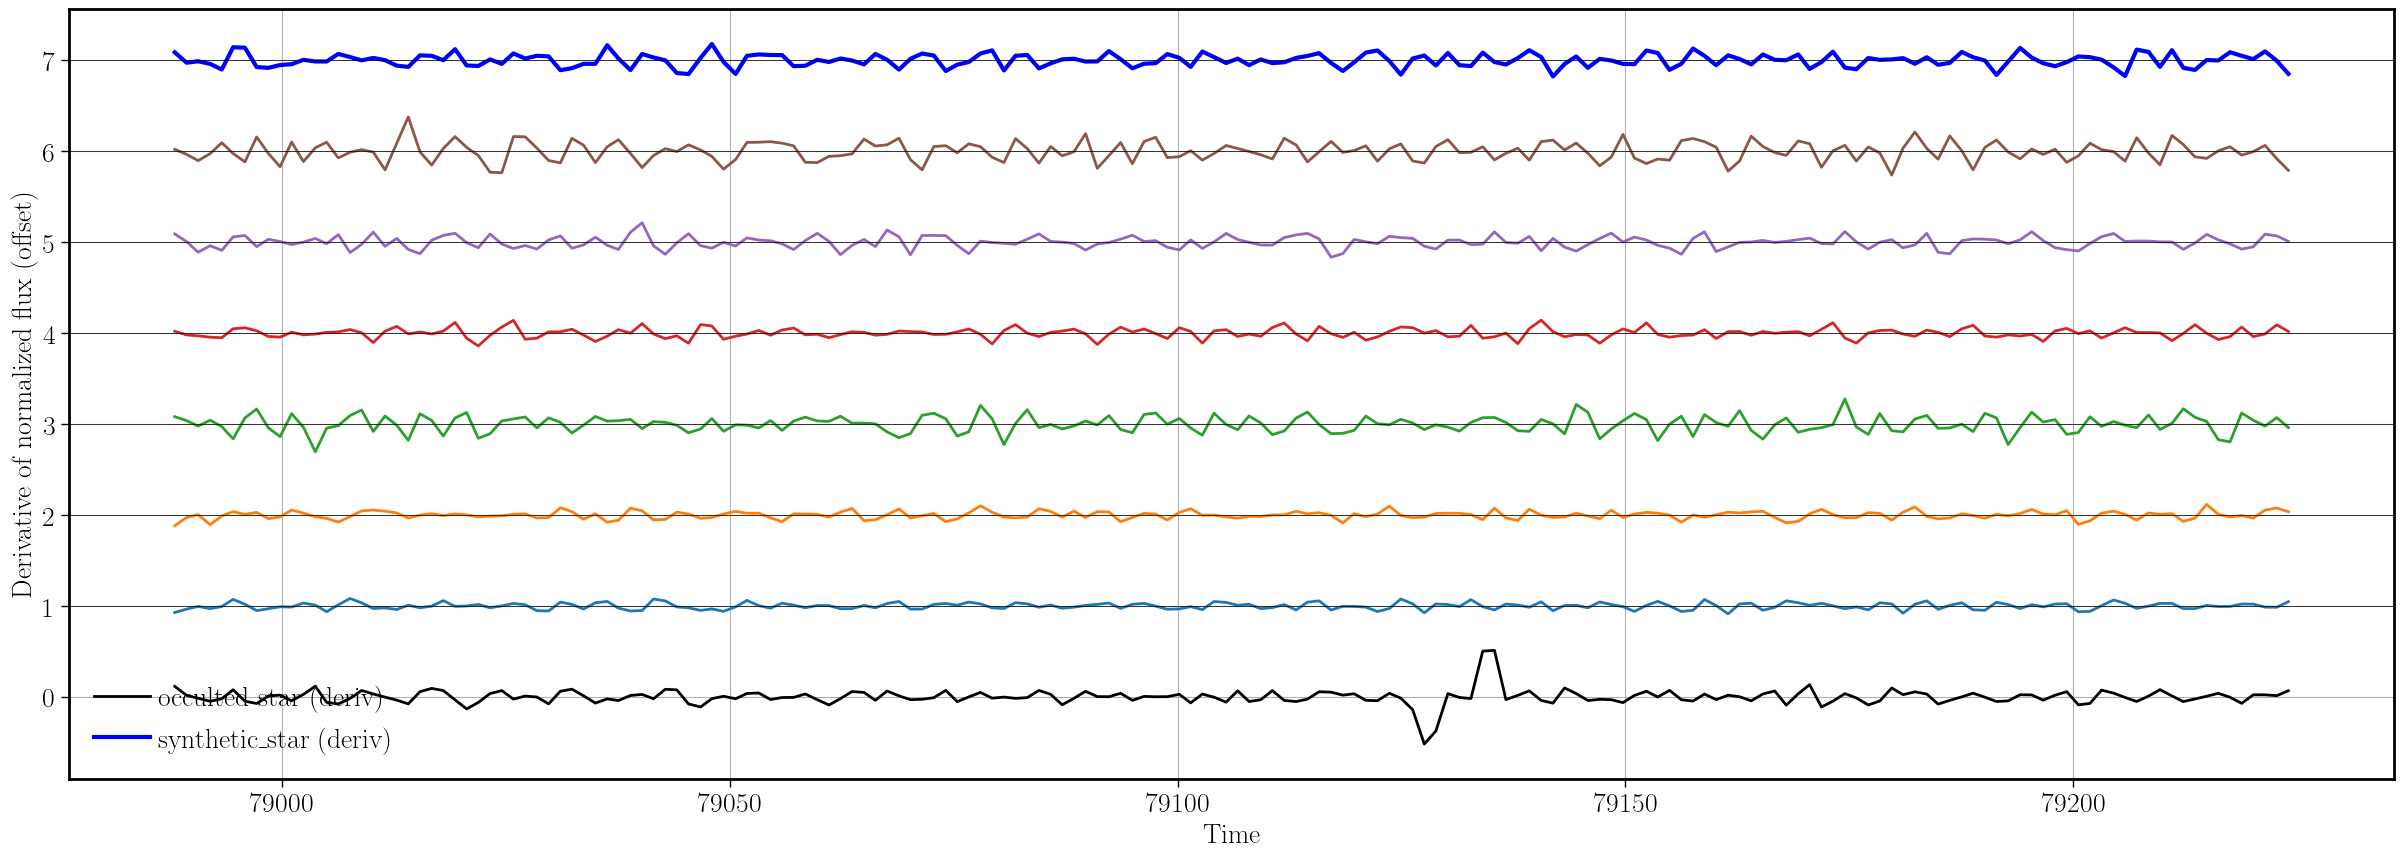

In [ ]:
plt.figure(figsize=(30, 10))

deriv_occulted = np.gradient(occulted_flux)

plt.plot(time_sec, deriv_occulted,
         color='black', linewidth=2, label='occulted star (deriv)')

for idx, row in f_norm.iterrows():

    offset = idx + 1

    deriv_star = np.gradient(row.values)

    if idx == 6:

        plt.plot(time_sec, deriv_star + offset,
                 linewidth=3, color='blue', label='synthetic_star (deriv)')

    else:

        flux = deriv_star + offset

        plt.plot(time_sec, flux, linewidth=2)

for y in range(1, 8):
    plt.axhline(y, color='black', linewidth=0.5, alpha=1)

plt.xlabel('Time')
plt.ylabel('Derivative of normalized flux (offset)')
plt.grid()
plt.legend()

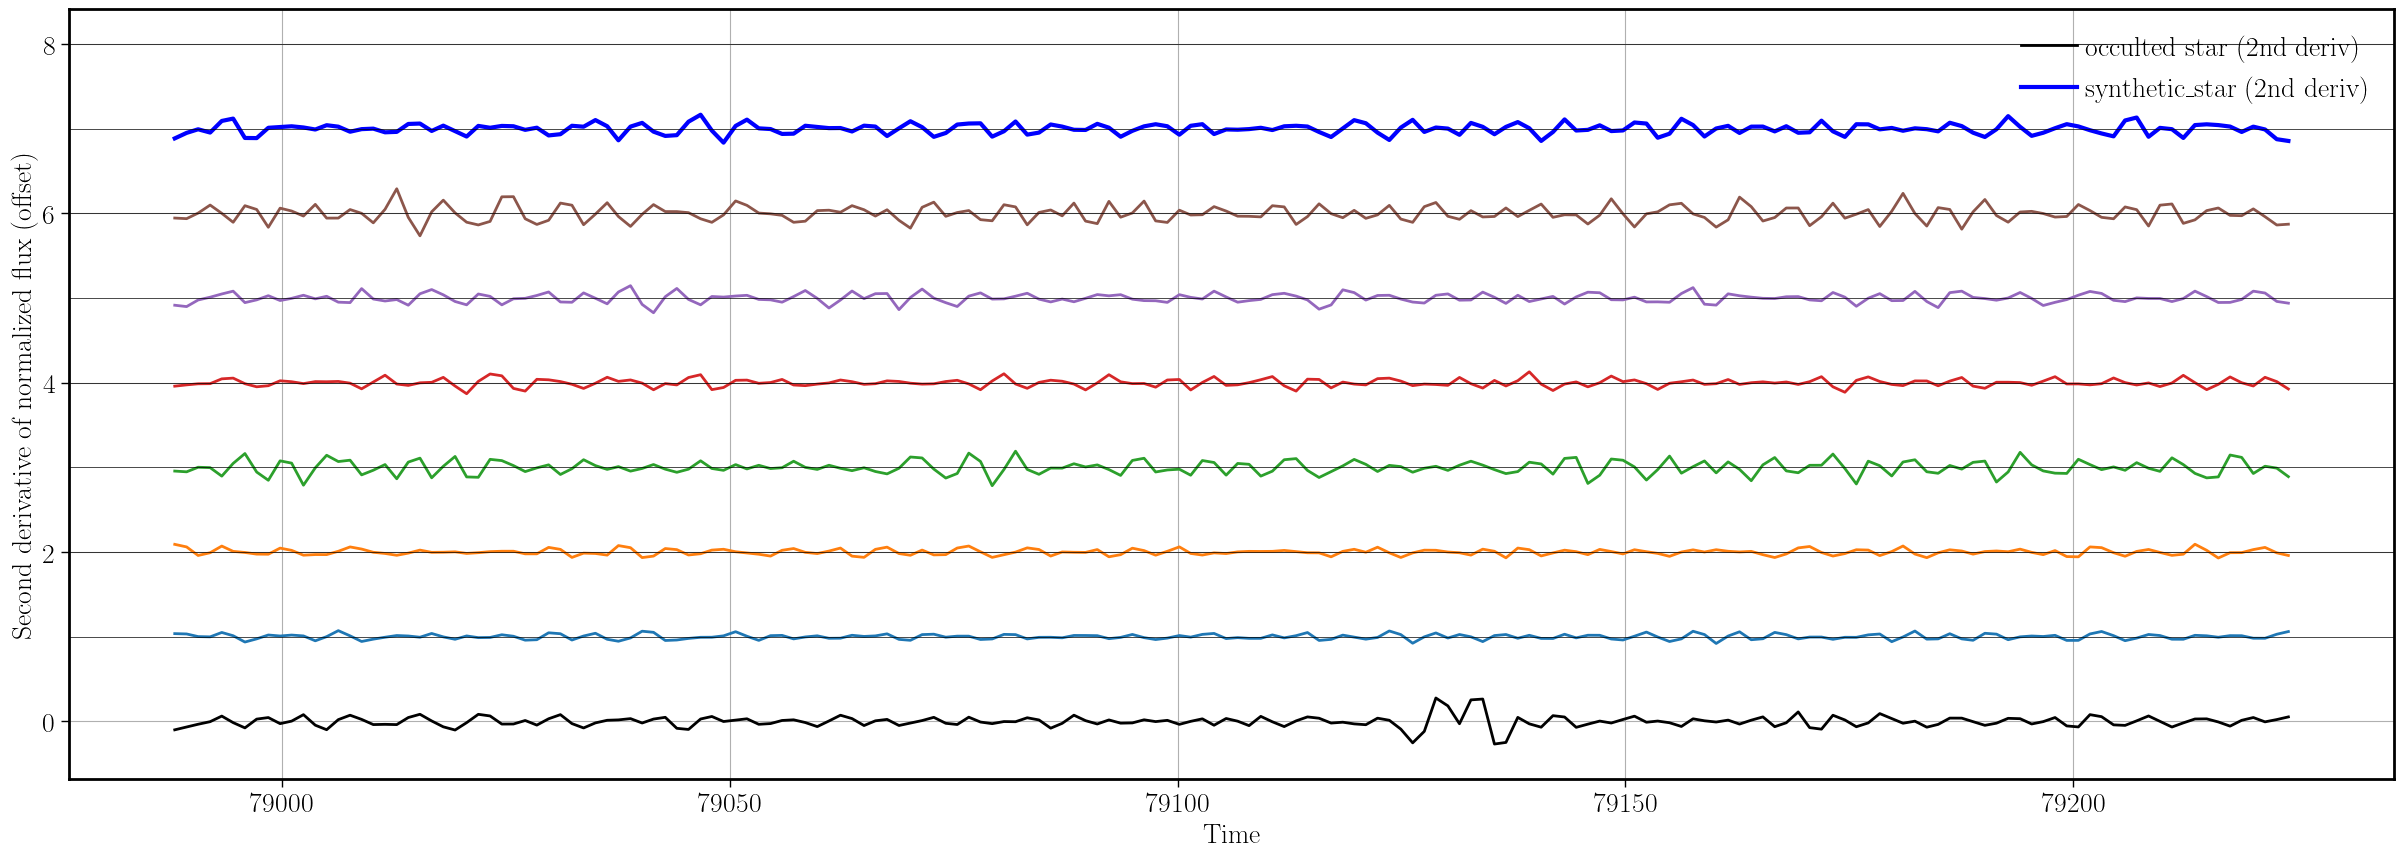

In [162]:
plt.figure(figsize=(30, 10))

deriv2_occulted = np.gradient(np.gradient(occulted_flux))

plt.plot(time_sec, deriv2_occulted,
         color='black', linewidth=2, label='occulted star (2nd deriv)')

for idx, row in f_norm.iterrows():

    offset = idx + 1

    # Segunda derivada de cada estrella
    deriv2_star = np.gradient(np.gradient(row.values))

    if idx == 6:

        plt.plot(time_sec, deriv2_star + offset,
                 linewidth=3, color='blue', label='synthetic_star (2nd deriv)')

    else:

        flux = deriv2_star + offset

        plt.plot(time_sec, flux, linewidth=2)

for y in range(1, 9):
    plt.axhline(y, color='black', linewidth=0.5, alpha=1)

plt.xlabel('Time')
plt.ylabel('Second derivative of normalized flux (offset)')
plt.grid()
plt.legend()

## Apendix 4 Synthetic star (Premium)


In [ ]:
df = f_norm.iloc[0:2]
star0 = df.iloc[0].values.flatten()
star1 = df.iloc[1].values.flatten()

array([1.00878282, 0.98580404, 1.04778885, 0.9966763 , 0.98759385,
       1.01613644, 1.06099799, 1.06921035, 0.99301229, 0.95546949,
       0.9801236 , 0.96034346, 1.07433171, 0.95590698, 0.966419  ,
       0.95406678, 1.05776061, 1.02536301, 1.02603616, 1.00844292,
       0.97006883, 1.02421484, 0.93815173, 1.02219959, 1.02831762,
       0.98062284, 1.03014441, 1.04460968, 1.01920787, 1.0280105 ,
       1.06479304, 1.10040986, 0.93701952, 0.9825151 , 1.02614343,
       0.97675906, 0.95059842, 1.02455618, 1.02796406, 1.07611659,
       0.96452006, 0.89872922, 1.07048359, 1.03238653, 1.0603344 ,
       0.99945737, 0.99381387, 0.92305896, 0.81811397, 0.94097052,
       0.98602398, 0.97487818, 0.93414232, 1.00996437, 0.95400146,
       0.96663648, 0.9692695 , 1.00130527, 0.89462424, 0.90056527,
       0.94867451, 0.86964506, 1.01683205, 0.99520141, 0.87026218,
       0.89812405, 0.96514323, 0.96966371, 0.95086215, 1.00016377,
       1.01585316, 0.9474986 , 0.94425388, 1.082043  , 1.01687